# ♟️ Chess ML — Clasificación de Nivel y Sistema de Recomendación de Repertorio

## Descripción del proyecto
Pipeline completo de Machine Learning sobre el repertorio de ajedrez de usuarios de Lichess. El flujo cubre desde la ingesta de partidas hasta la generación de un plan de estudio personalizado.

## Estructura del notebook
| # | Sección | Contenido |
|---|---|---|
| 0 | Imports | Librerías y configuración global |
| 1 | Rutas | Resolución de paths y directorios de salida |
| 2 | Carga y feature engineering | Reconstrucción del dataset desde fuente canónica |
| 3 | Split | Train/test por usuario + corrección de leakage |
| 4 | Experimentos A/B/C | CV honesto a nivel de partida |
| 5 | Dataset usuario | Agregación a una fila por usuario |
| 6 | Comparativa modelos | RF vs SVM vs KNN vs LightGBM |
| 7 | Modelo final | Entrenamiento, calibración y exportación |
| 8 | Análisis errores | Confusion matrix y perfil de errores |
| 9 | Clustering partidas | Grupos naturales de comportamiento |
| 10 | Clustering aperturas | Sin leakage de rating |
| 11 | Perfil usuario | Agregación de etiquetas de apertura |
| 12 | Decision Tree | Reglas interpretables de clasificación |
| 13 | Recomendador v2 | Basado en perfil individual |
| 14 | Recomendador KNN | Basado en similitud entre usuarios |
| 15 | Plan unificado | Fusión v2 + KNN con deduplicación |


## 0. Imports y configuración global

Carga de todas las librerías del proyecto. Se configuran estilos de visualización globales para garantizar consistencia en todos los plots del notebook.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json
from pathlib import Path
from datetime import datetime
from lightgbm import LGBMClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Librerías cargadas')

Librerías cargadas


## 1. Configuración de rutas

Resolución automática de paths relativos a la ubicación del notebook, siguiendo la estructura de carpetas del proyecto:

```
Proyecto ML/
├── src/
│   ├── data/
│   │   ├── CSV/          ← datasets de entrada y salida
│   │   ├── PKL/          ← modelos y objetos serializados
│   │   ├── Backups/      ← copias de seguridad
│   │   ├── train.csv     ← split de entrenamiento
│   │   └── test.csv      ← split de evaluación
│   ├── model/production/ ← modelo final exportado
│   └── notebooks/        ← este notebook
└── resources/engines/    ← Stockfish
```


In [2]:
NOTEBOOK_DIR = Path().resolve()

# ── Localizar las dos fuentes del dataset ──────────────────────────────────────
# El pipeline ETL genera dos CSV con propósitos distintos:
#   · master_dataset_ml.csv     → fuente canónica de Stockfish (ACL_Post_Teo, Fin_Teoria)
#   · master_game_level_ml.csv  → metadatos enriquecidos (Apertura, Color, Usuario, Victoria...)
# Trabajamos con ambos para reconstruir las features derivadas desde la fuente raw
# y garantizar coherencia con el pipeline de inferencia.
def _find(*candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

DATA_PATH_RAW = _find(
    NOTEBOOK_DIR / 'master_dataset_ml.csv',
    NOTEBOOK_DIR.parent / 'data' / 'CSV' / 'master_dataset_ml.csv',
    NOTEBOOK_DIR.parent.parent / 'src' / 'data' / 'CSV' / 'master_dataset_ml.csv',
)
DATA_PATH_FULL = _find(
    NOTEBOOK_DIR / 'master_game_level_ml.csv',
    NOTEBOOK_DIR.parent / 'data' / 'CSV' / 'master_game_level_ml.csv',
    NOTEBOOK_DIR.parent.parent / 'src' / 'data' / 'CSV' / 'master_game_level_ml.csv',
)
for p, name in [(DATA_PATH_RAW, 'master_dataset_ml.csv'),
                (DATA_PATH_FULL, 'master_game_level_ml.csv')]:
    if p is None:
        raise FileNotFoundError(f'{name} no encontrado en ninguna ruta candidata.')

# Alias retro-compatible con celdas posteriores que usan DATA_PATH
DATA_PATH = DATA_PATH_FULL

# ── Directorios de salida (se crean automáticamente si no existen) ─────────────
DATA_OUT  = NOTEBOOK_DIR.parent / 'data'               # src/data/
CSV_OUT   = DATA_OUT / 'CSV'                            # src/data/CSV/
PKL_OUT   = DATA_OUT / 'PKL'                            # src/data/PKL/
MODEL_OUT = NOTEBOOK_DIR.parent / 'model' / 'production'  # src/model/production/

for d in [DATA_OUT, CSV_OUT, PKL_OUT, MODEL_OUT]:
    d.mkdir(parents=True, exist_ok=True)

# ── Variables de cadena para celdas que usan rutas como strings ───────────────
RUTA_BASE = str(NOTEBOOK_DIR)   # directorio del notebook
RUTA_DATA = str(CSV_OUT)        # directorio CSV
RUTA_PKL  = str(PKL_OUT)        # directorio PKL

print(f' Fuente raw   : {DATA_PATH_RAW}')
print(f' Fuente full  : {DATA_PATH_FULL}')
print(f' CSV out      : {CSV_OUT}')
print(f' PKL out      : {PKL_OUT}')
print(f' Model out    : {MODEL_OUT}')


 Fuente raw   : C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV\master_dataset_ml.csv
 Fuente full  : C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV\master_game_level_ml.csv
 CSV out      : C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV
 PKL out      : C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\PKL
 Model out    : C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\model\production


## 2. Carga de datos y feature engineering

### Motivación: ¿por qué reconstruir las features dentro del notebook?

El CSV `master_game_level_ml.csv` viene del pipeline ETL del proyecto e incluye **features derivadas pre-calculadas** (`acl_winsorized`, `accuracy_game`, `game_risk_index`). Sin embargo, estas columnas pueden haber sido generadas con valores intermedios distintos a los del estado actual del dataset (por ejemplo, antes de que Stockfish completase el análisis de todas las partidas). Para que el entrenamiento del clustering sea **trazable y reproducible**, recalculamos todas las features derivadas dentro de este notebook a partir de la fuente canónica `master_dataset_ml.csv`, que contiene los valores raw de Stockfish (`ACL_Post_Teo`).

### Definición formal de las features

Sea $a$ el ACL post-teoría (centipeones medios perdidos por jugada después de salir del libro) y $t$ la profundidad teórica alcanzada (jugadas que coinciden con la base teórica).

| Feature | Fórmula | Interpretación |
|---|---|---|
| `acl_winsorized` | $\min(a, 500)$ | ACL acotado para evitar outliers extremos |
| `accuracy_game` | $\max(0,\ 103.17\,e^{-0.04354 \cdot a} - 3.17)$ | Accuracy post-teoría (fórmula Lichess) |
| `teoria_norm` | $t / 15$ | Profundidad teórica normalizada |
| `game_risk_index` | $\frac{t}{15} \cdot (100 - \text{accuracy\_game})$ | Riesgo: combina teoría profunda con bajo rendimiento |

Las constantes `ACL_WINSOR_CAP = 500` y `FIN_TEORIA_MAX = 15` se definen explícitamente como variables del notebook para que cualquier cambio en el pipeline de inferencia (`app_16.py`) pueda referenciar los mismos valores y evitar drift entre entrenamiento e inferencia.

### Etiquetado de niveles de rating

| Clase | Rating | Color |
|---|---|---|
| `principiante` | < 1400 | Verde |
| `intermedio` | 1400 – 1800 | Azul |
| `avanzado` | ≥ 1800 | Rojo |

Se definen dos grupos de features con distinto tratamiento posterior:
- **`FEATURES_GAME`**: métricas por partida individual (no dependen del historial).
- **`FEATURES_USER`**: agregados del usuario — deben recalcularse **solo con train**.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.1 — Constantes y función canónica del pipeline de feature engineering
#
# Importamos `acpl_to_accuracy` directamente desde el módulo del ETL del
# proyecto (`src/util/chess_game_level_augmentation.py`). Así garantizamos
# que el notebook y el pipeline de inferencia usan la MISMA función,
# eliminando cualquier posibilidad de drift entre training e inference.
# ═══════════════════════════════════════════════════════════════════════════════
import sys

# Añadir el directorio src/ al path para importar utilidades del proyecto
SRC_DIR = NOTEBOOK_DIR.parent.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    from src.util.chess_game_level_augmentation import acpl_to_accuracy
    print('✅ acpl_to_accuracy importada desde src.util.chess_game_level_augmentation')
    _FUENTE_ACCURACY = 'src.util.chess_game_level_augmentation'
except ImportError:
    # Fallback: si la importación falla, usar la fórmula de Lichess.
    # ⚠️  Esto puede generar drift con respecto al pipeline real; revisar el path.
    import warnings
    warnings.warn(
        'No se pudo importar acpl_to_accuracy del módulo del proyecto. '
        'Usando fórmula de Lichess como fallback. Verifica el path SRC_DIR.',
        RuntimeWarning,
    )
    def acpl_to_accuracy(acpl):
        return max(0.0, 103.1668 * np.exp(-0.04354 * acpl) - 3.1669)
    _FUENTE_ACCURACY = 'fallback Lichess'

# ── Constantes del pipeline ────────────────────────────────────────────────────
# Estos valores deben coincidir EXACTAMENTE con los del pipeline de inferencia.
ACL_WINSOR_CAP = 500     # Cap superior del ACL (cp) para acotar outliers
FIN_TEORIA_MAX = 15      # Profundidad teórica máxima considerada (jugadas)

print(f'\n⚙️  ACL_WINSOR_CAP       = {ACL_WINSOR_CAP} cp')
print(f'⚙️  FIN_TEORIA_MAX       = {FIN_TEORIA_MAX} jugadas')
print(f'⚙️  acpl_to_accuracy desde: {_FUENTE_ACCURACY}')

# Mostrar ejemplos de valores devueltos por la función para verificar comportamiento
print(f'\n📐 Calibración acpl_to_accuracy:')
for acpl in [0, 25, 50, 100, 200, 300, 500]:
    print(f'   acpl_to_accuracy({acpl:>4}) = {acpl_to_accuracy(acpl):.2f}')


✅ acpl_to_accuracy importada desde src.util.chess_game_level_augmentation

⚙️  ACL_WINSOR_CAP       = 500 cp
⚙️  FIN_TEORIA_MAX       = 15 jugadas
⚙️  acpl_to_accuracy desde: src.util.chess_game_level_augmentation

📐 Calibración acpl_to_accuracy:
   acpl_to_accuracy(   0) = 100.00
   acpl_to_accuracy(  25) = 91.62
   acpl_to_accuracy(  50) = 83.95
   acpl_to_accuracy( 100) = 70.47
   acpl_to_accuracy( 200) = 49.66
   acpl_to_accuracy( 300) = 34.99
   acpl_to_accuracy( 500) = 17.38


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.2 — Carga y reconstrucción del dataset
# Combinamos las dos fuentes y recalculamos las features derivadas desde RAW.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Carga de las dos fuentes ───────────────────────────────────────────────────
df_raw  = pd.read_csv(DATA_PATH_RAW)
df_full = pd.read_csv(DATA_PATH_FULL)

print(f'📥 master_dataset_ml.csv      → {df_raw.shape}   (fuente canónica de Stockfish)')
print(f'📥 master_game_level_ml.csv   → {df_full.shape}   (metadatos enriquecidos)')

# ── Eliminar columnas pre-calculadas que vamos a regenerar ─────────────────────
# Estas pueden venir del CSV en estado inconsistente con el ACL actual; las
# recalculamos desde la fuente raw para garantizar coherencia.
cols_a_regenerar = [
    'ACL_Post_Teo', 'acl_winsorized', 'accuracy_game',
    'game_risk_index', 'Accuracy', 'AccAjustada', 'teoria_norm',
]
df_base = df_full.drop(
    columns=[c for c in cols_a_regenerar if c in df_full.columns]
)

# ── Merge: traer ACL_Post_Teo desde la fuente canónica ─────────────────────────
# Inner join: nos quedamos solo con las partidas que tienen ACL real calculado.
df = df_base.merge(
    df_raw[['Game_ID', 'ACL_Post_Teo']],
    on='Game_ID', how='inner',
).reset_index(drop=True)

print(f'🔗 Tras merge inner por Game_ID: {df.shape}   ({len(df):,} partidas con ACL válido)')

# ── Recalcular features dependientes de ACL_Post_Teo ───────────────────────────
df['acl_winsorized']  = df['ACL_Post_Teo'].clip(upper=ACL_WINSOR_CAP)
df['accuracy_game']   = df['acl_winsorized'].apply(acpl_to_accuracy)
df['teoria_norm']     = df['Fin_Teoria'] / FIN_TEORIA_MAX
df['game_risk_index'] = df['teoria_norm'] * (100 - df['accuracy_game'])

# Asegurar que color_bin existe (usado por celdas posteriores)
if 'color_bin' not in df.columns:
    df['color_bin'] = (df['Color'].str.lower().str.startswith('w') |
                       df['Color'].str.lower().str.startswith('b')).astype(int)
    df.loc[df['Color'].str.lower().isin(['white', 'blancas']), 'color_bin'] = 1
    df.loc[df['Color'].str.lower().isin(['black', 'negras']), 'color_bin'] = 0

# ── Diagnóstico de las distribuciones tras el recálculo ────────────────────────
print(f'\n📊 Distribuciones de features derivadas:')
stats = df[['ACL_Post_Teo', 'acl_winsorized', 'accuracy_game',
            'teoria_norm', 'game_prep_score', 'game_risk_index']].describe().round(2)
print(stats.loc[['mean', 'std', 'min', '50%', 'max']].to_string())


📥 master_dataset_ml.csv      → (17987, 8)   (fuente canónica de Stockfish)
📥 master_game_level_ml.csv   → (18059, 29)   (metadatos enriquecidos)
🔗 Tras merge inner por Game_ID: (17986, 23)   (17,986 partidas con ACL válido)

📊 Distribuciones de features derivadas:
      ACL_Post_Teo  acl_winsorized  accuracy_game  teoria_norm  game_prep_score  game_risk_index
mean        120.92          107.96          74.32         0.54             0.54            13.80
std         239.51          128.90          24.55         0.25             0.25            15.13
min           0.00            0.00          17.38         0.00             0.00             0.00
50%          61.20           61.20          80.72         0.53             0.53             9.24
max       10084.00          500.00         100.00         1.27             1.27            82.62


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.3 — Etiquetado de niveles y definición de grupos de features
# ═══════════════════════════════════════════════════════════════════════════════

# ── Etiquetado de niveles a partir del rating ──────────────────────────────────
BINS_3    = [0, 1400, 1800, 5000]
LABELS_3  = ['principiante', 'intermedio', 'avanzado']
CAT_ORDER = LABELS_3
PALETTE   = {'principiante': '#3B6D11', 'intermedio': '#185FA5', 'avanzado': '#993556'}

df['nivel_3class'] = pd.cut(
    df['Rating_Usuario'], bins=BINS_3, labels=LABELS_3, right=False
).astype(str)

# ── Definición de grupos de features ───────────────────────────────────────────
# Features a nivel de partida (no dependen del historial del usuario)
FEATURES_GAME = [
    f for f in [
        'Fin_Teoria', 'acl_winsorized', 'game_risk_index',
        'game_prep_score', 'is_theory_expert', 'is_feeling_natural',
        'is_critical_point', 'color_bin', 'Victoria',
    ] if f in df.columns
]

# Features de contexto de usuario → se recalcularán solo con train (Sección 3)
FEATURES_USER = [
    'win_rate_user', 'avg_teoria_user', 'avg_acl_user',
    'std_acl_user', 'n_games_user', 'consistency_score',
]
FEATURES_USER = [f for f in FEATURES_USER if f in df.columns]

TARGET = 'nivel_3class'
le = LabelEncoder().fit(CAT_ORDER)

# ── Resumen ────────────────────────────────────────────────────────────────────
dist = df[TARGET].value_counts().reindex(CAT_ORDER)
print(f'Distribución por nivel:\n{dist.to_string()}')
print(f'Ratio max/min: {dist.max()/dist.min():.2f}x')
print(f'\nFeatures de partida ({len(FEATURES_GAME)}): {FEATURES_GAME}')
print(f'Features de usuario ({len(FEATURES_USER)}): {FEATURES_USER}')


Distribución por nivel:
nivel_3class
principiante    5072
intermedio      4531
avanzado        8383
Ratio max/min: 1.85x

Features de partida (9): ['Fin_Teoria', 'acl_winsorized', 'game_risk_index', 'game_prep_score', 'is_theory_expert', 'is_feeling_natural', 'is_critical_point', 'color_bin', 'Victoria']
Features de usuario (6): ['win_rate_user', 'avg_teoria_user', 'avg_acl_user', 'std_acl_user', 'n_games_user', 'consistency_score']


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.4 — Inspección rápida del dataset reconstruido
# ═══════════════════════════════════════════════════════════════════════════════
print('Columnas disponibles:')
print(sorted(df.columns.tolist()))
print(f'\nShape: {df.shape}')
print(f'Usuarios únicos: {df["Usuario"].nunique()}')
print(f'\nEjemplo de un usuario (primeras 5 partidas):')
u = df['Usuario'].iloc[0]
print(df[df['Usuario'] == u][
    ['Rating_Usuario', 'nivel_3class', 'Fin_Teoria', 'ACL_Post_Teo',
     'acl_winsorized', 'accuracy_game', 'game_risk_index']
].head(5).to_string())


Columnas disponibles:
['ACL_Post_Teo', 'Apertura', 'Color', 'Fin_Teoria', 'Game_ID', 'Rating_Usuario', 'Usuario', 'Victoria', 'accuracy_game', 'accuracy_user', 'acl_winsorized', 'avg_acl_user', 'avg_teoria_user', 'color_bin', 'consistency_score', 'delta_acl_vs_user', 'game_prep_score', 'game_risk_index', 'is_critical_point', 'is_feeling_natural', 'is_theory_expert', 'n_games_user', 'nivel_3class', 'nivel_num', 'std_acl_user', 'teoria_norm', 'win_rate_user']

Shape: (17986, 27)
Usuarios únicos: 98

Ejemplo de un usuario (primeras 5 partidas):
   Rating_Usuario nivel_3class  Fin_Teoria  ACL_Post_Teo  acl_winsorized  accuracy_game  game_risk_index
0            2360     avanzado          15         136.0           136.0          62.13        37.870000
1            2360     avanzado          17          73.0            73.0          77.45        25.556667
2            2360     avanzado           9         129.3           129.3          63.60        21.840000
3            2360     avanzado  

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.5 — Validación del feature engineering
# Sanity check: comprobamos que las distribuciones de las features derivadas
# están en rangos coherentes. Si alguna estadística cae fuera del rango
# esperado, lanzamos un warning para alertar de un posible drift.
# ═══════════════════════════════════════════════════════════════════════════════
import warnings

# Rangos esperados de las features (derivados del comportamiento del pipeline)
RANGOS_ESPERADOS = {
    'Fin_Teoria':      {'mean': (5, 12)},
    'acl_winsorized':  {'mean': (50, 200), 'max': (450, 500)},
    'accuracy_game':   {'mean': (10, 80)},
    'game_prep_score': {'mean': (0.3, 0.7)},
    'game_risk_index': {'mean': (3, 30)},
}

print('🔎 Validación de rangos por feature:\n')
print(f'   {"Feature":<20} {"mean":>10} {"max":>10} {"rango esperado mean":<25} {"estado"}')
print(f'   {"-"*20} {"-"*10} {"-"*10} {"-"*25} {"-"*10}')

alertas = 0
for feat, rangos in RANGOS_ESPERADOS.items():
    if feat not in df.columns:
        continue
    m = df[feat].mean()
    mx = df[feat].max()
    esperado = rangos.get('mean', (None, None))
    en_rango = esperado[0] <= m <= esperado[1]
    estado = '' if en_rango else ' FUERA DE RANGO'
    print(f'   {feat:<20} {m:>10.2f} {mx:>10.2f} '
          f'[{esperado[0]:.2f}, {esperado[1]:.2f}]{"":<10} {estado}')
    if not en_rango:
        alertas += 1

if alertas == 0:
    print(f'\n Feature engineering coherente con los rangos esperados.')
else:
    warnings.warn(
        f'{alertas} feature(s) fuera del rango esperado. '
        f'Posible drift en el ETL — revisa la función acpl_to_accuracy.',
        RuntimeWarning,
    )


🔎 Validación de rangos por feature:

   Feature                    mean        max rango esperado mean       estado
   -------------------- ---------- ---------- ------------------------- ----------
   Fin_Teoria                 8.06      19.00 [5.00, 12.00]           
   acl_winsorized           107.96     500.00 [50.00, 200.00]           
   accuracy_game             74.32     100.00 [10.00, 80.00]           
   game_prep_score            0.54       1.27 [0.30, 0.70]           
   game_risk_index           13.80      82.62 [3.00, 30.00]           

 Feature engineering coherente con los rangos esperados.


## 3. Split train/test — corrección de data leakage

### Problema detectado
Las features de usuario (`win_rate_user`, `avg_acl_user`, etc.) del dataset original
fueron calculadas sobre **todas** las partidas (incluidas las de test), introduciendo
**data leakage**: el modelo veía indirectamente información del futuro.

### Solución implementada
1. Dividir por **usuario** (no por partida) con `GroupShuffleSplit` → 80% train / 20% test.
   Ningún usuario aparece en ambos splits.
2. Recalcular features de usuario **exclusivamente** con partidas de train.
3. Imputar con **mediana de train** para usuarios de test sin historial en train.

Los splits limpios se guardan en `src/data/train.csv` y `src/data/test.csv`.


In [8]:
# ── Split por usuario: garantiza que un usuario no esté en train y test ────────
GROUPS = df['Usuario']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df[TARGET], groups=GROUPS))

df_train_raw = df.iloc[train_idx].copy().reset_index(drop=True)
df_test_raw  = df.iloc[test_idx].copy().reset_index(drop=True)


# ── Fix de leakage: recalcular features de usuario solo con train ──────────────
def recompute_user_features(df_train: pd.DataFrame,
                             df_test:  pd.DataFrame) -> tuple:
    """
    Recalcula las features de contexto de usuario usando únicamente df_train.
    Los usuarios de test que no aparezcan en train reciben la mediana de train
    como valor de imputación.

    Parameters
    ----------
    df_train : DataFrame de entrenamiento (partidas).
    df_test  : DataFrame de evaluación (partidas).

    Returns
    -------
    df_tr, df_te : DataFrames con features de usuario limpias (sin leakage).
    """
    # Calcular estadísticas SOLO sobre partidas de entrenamiento
    user_stats = df_train.groupby('Usuario').agg(
        win_rate_user   = ('Victoria',       'mean'),
        avg_teoria_user = ('Fin_Teoria',     'mean'),
        avg_acl_user    = ('acl_winsorized', 'mean'),
        std_acl_user    = ('acl_winsorized', 'std'),
        n_games_user    = ('Game_ID',        'count'),
    ).reset_index()

    # Consistencia: ratio inverso de variabilidad del ACL (0=muy variable, 1=estable)
    user_stats['std_acl_user'] = user_stats['std_acl_user'].fillna(0)
    user_stats['consistency_score'] = (
        1 - (user_stats['std_acl_user'] /
             (user_stats['avg_acl_user'] + 1e-9)).clip(0, 1)
    )

    UCOLS = ['win_rate_user', 'avg_teoria_user', 'avg_acl_user',
             'std_acl_user', 'n_games_user', 'consistency_score']

    # Mediana de train para imputar usuarios no vistos en test
    medians = user_stats[UCOLS].median()

    # Sustituir versión con leakage por la versión limpia
    drop  = [c for c in UCOLS if c in df_train.columns]
    df_tr = df_train.drop(columns=drop).merge(user_stats, on='Usuario', how='left')
    df_te = df_test.drop(columns=drop).merge(user_stats, on='Usuario', how='left')

    # Imputar NaN con mediana de train
    for col, val in medians.items():
        df_te[col] = df_te[col].fillna(val)
        df_tr[col] = df_tr[col].fillna(val)

    return df_tr, df_te


df_train, df_test = recompute_user_features(df_train_raw, df_test_raw)

# ── Verificación de integridad: el solapamiento debe ser cero ─────────────────
overlap = set(df_train['Usuario']) & set(df_test['Usuario'])
print(f'Usuarios solapados train/test: {len(overlap)} (debe ser 0)')
print(f'Train: {len(df_train):,} partidas | {df_train["Usuario"].nunique()} usuarios')
print(f'Test:  {len(df_test):,} partidas  | {df_test["Usuario"].nunique()} usuarios')

# ── Guardar splits limpios en src/data/ ───────────────────────────────────────
df_train.to_csv(DATA_OUT / 'train.csv', index=False)
df_test.to_csv(DATA_OUT / 'test.csv',   index=False)
print(f'\n train.csv → {DATA_OUT / "train.csv"}')
print(f' test.csv  → {DATA_OUT / "test.csv"}')


Usuarios solapados train/test: 0 (debe ser 0)
Train: 14,456 partidas | 78 usuarios
Test:  3,530 partidas  | 20 usuarios

 train.csv → C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\train.csv
 test.csv  → C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\test.csv


## 4. Experimentos A / B / C — clasificación a nivel de partida

Comparación de tres configuraciones de features mediante **StratifiedGroupKFold(5)**.
Los grupos son usuarios, para que partidas del mismo jugador no aparezcan
simultáneamente en train y validación.

| Experimento | Features | Observación esperada |
|---|---|---|
| **A** | Solo partida | Línea base — señal débil por partida individual |
| **B** | Solo usuario | Alto CV pero gran gap en test → evidencia de leakage residual |
| **C** | Combinado | Mejor CV; puede sobre-ajustar features de usuario |

> El gap CV↔Test en B y C motiva el cambio de estrategia hacia modelos a nivel de usuario.


In [9]:
FEATURES_ALL = FEATURES_GAME + FEATURES_USER

y_train_enc  = le.transform(df_train[TARGET])
y_test_enc   = le.transform(df_test[TARGET])
groups_train = df_train['Usuario']   # índices ya reseteados

sgkf = StratifiedGroupKFold(n_splits=5)


def run_experiment(features: list, label: str,
                   max_depth=8, min_samples_leaf=20) -> dict:
    """Entrena RF con CV honesto y evalúa en test. Devuelve métricas."""
    X_tr = df_train[features].fillna(0)
    X_te = df_test[features].fillna(0)

    model = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=max_depth, min_samples_leaf=min_samples_leaf,
        random_state=42, n_jobs=-1
    )

    # CV con grupos limpios
    fold_f1s = []
    for tr_cv, val_cv in sgkf.split(X_tr, y_train_enc, groups=groups_train):
        model.fit(X_tr.iloc[tr_cv], y_train_enc[tr_cv])
        f1 = f1_score(y_train_enc[val_cv],
                      model.predict(X_tr.iloc[val_cv]),
                      average='weighted')
        fold_f1s.append(f1)

    # Entrenamiento final y evaluación en test
    model.fit(X_tr, y_train_enc)
    y_pred = model.predict(X_te)
    f1_te  = f1_score(y_test_enc, y_pred, average='weighted')
    cv_mean = np.mean(fold_f1s)

    print(f'\n{"-"*50}')
    print(f'  {label}')
    print(f'  CV F1  : {cv_mean:.3f} ± {np.std(fold_f1s):.3f}')
    print(f'  Test F1: {f1_te:.3f}  (gap: {cv_mean - f1_te:+.3f})')
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

    return {'label': label, 'model': model,
            'cv_f1': cv_mean, 'test_f1': f1_te,
            'features': features, 'y_pred': y_pred}


res_A = run_experiment(FEATURES_GAME, 'A — Solo partida')
res_B = run_experiment(FEATURES_USER, 'B — Solo contexto usuario')
res_C = run_experiment(FEATURES_ALL,  'C — Combinado')


--------------------------------------------------
  A — Solo partida
  CV F1  : 0.512 ± 0.031
  Test F1: 0.422  (gap: +0.090)
              precision    recall  f1-score   support

    avanzado       0.43      0.49      0.46       986
  intermedio       0.51      0.30      0.38      1621
principiante       0.37      0.58      0.45       923

    accuracy                           0.43      3530
   macro avg       0.44      0.46      0.43      3530
weighted avg       0.45      0.43      0.42      3530


--------------------------------------------------
  B — Solo contexto usuario
  CV F1  : 0.801 ± 0.082
  Test F1: 0.289  (gap: +0.512)
              precision    recall  f1-score   support

    avanzado       0.00      0.00      0.00       986
  intermedio       0.46      1.00      0.63      1621
principiante       0.00      0.00      0.00       923

    accuracy                           0.46      3530
   macro avg       0.15      0.33      0.21      3530
weighted avg       0.21     

In [10]:
# ── Distribución de usuarios y partidas por nivel en cada split ────────────────
print('Usuarios por nivel en TRAIN:')
print(df_train.groupby('nivel_3class')['Usuario'].nunique().reindex(CAT_ORDER))
print('\nUsuarios por nivel en TEST:')
print(df_test.groupby('nivel_3class')['Usuario'].nunique().reindex(CAT_ORDER))
print('\nPartidas por nivel en TEST:')
print(df_test['nivel_3class'].value_counts().reindex(CAT_ORDER))


Usuarios por nivel en TRAIN:
nivel_3class
principiante    26
intermedio      15
avanzado        38
Name: Usuario, dtype: int64

Usuarios por nivel en TEST:
nivel_3class
principiante    7
intermedio      8
avanzado        5
Name: Usuario, dtype: int64

Partidas por nivel en TEST:
nivel_3class
principiante     923
intermedio      1621
avanzado         986
Name: count, dtype: int64


## 5. Dataset a nivel de usuario

Con solo 98 usuarios, la clasificación a nivel de partida individual sufre de alta
varianza y mal generaliza (demostrado en la sección anterior).

La solución es agregar todas las partidas de cada usuario en **una única fila**
que capture su perfil global de comportamiento.

**Features del perfil de usuario**:

| Feature | Descripción |
|---|---|
| `win_rate` | Tasa de victorias |
| `avg_teoria` | Profundidad teórica media |
| `avg_acl` / `std_acl` | Pérdida de CP media y variabilidad |
| `avg_prep` / `avg_risk` | Preparación y riesgo medio por partida |
| `pct_theory_exp` | % de partidas como experto teórico |
| `pct_feeling_nat` | % de partidas con buen feeling posicional |
| `pct_critical` | % de partidas en punto crítico |
| `n_games` | Volumen de datos |


In [11]:
# Celda nueva — crear dataset a nivel de usuario (una fila por usuario)
user_df = df.groupby('Usuario').agg(
    Rating_Usuario  = ('Rating_Usuario',  'first'),
    nivel_3class    = ('nivel_3class',    'first'),
    win_rate        = ('Victoria',        'mean'),
    avg_teoria      = ('Fin_Teoria',      'mean'),
    avg_acl         = ('acl_winsorized',  'mean'),
    std_acl         = ('acl_winsorized',  'std'),
    n_games         = ('Game_ID',         'count'),
    avg_prep        = ('game_prep_score', 'mean'),
    avg_risk        = ('game_risk_index', 'mean'),
    pct_theory_exp  = ('is_theory_expert','mean'),
    pct_feeling_nat = ('is_feeling_natural','mean'),
    pct_critical    = ('is_critical_point', 'mean'),
    consistency     = ('consistency_score', 'first'),
).reset_index()

user_df['std_acl'] = user_df['std_acl'].fillna(0)

print(f"Dataset a nivel usuario: {user_df.shape}")
print(f"\nDistribución:")
print(user_df['nivel_3class'].value_counts().reindex(CAT_ORDER))
print(f"\nEjemplo:")
print(user_df.head(3).to_string())

Dataset a nivel usuario: (98, 14)

Distribución:
nivel_3class
principiante    33
intermedio      22
avanzado        43
Name: count, dtype: int64

Ejemplo:
         Usuario  Rating_Usuario  nivel_3class  win_rate  avg_teoria     avg_acl     std_acl  n_games  avg_prep   avg_risk  pct_theory_exp  pct_feeling_nat  pct_critical  consistency
0      AADESHGOW            1404    intermedio  0.542929    7.636364  130.510101  155.295263      198  0.509088  14.779949        0.262626         0.393939           0.0          NaN
1  Abdulghani-HB            2000      avanzado  0.542500   10.410000   94.476000  121.128392      200  0.694000  16.922467        0.595000         0.130000           0.0          NaN
2      AbhiramME            1118  principiante  0.365079    5.513228  148.003175  164.746418      189  0.367550  11.876772        0.058201         0.677249           0.0          NaN


## 6. Comparativa de modelos — selección del mejor

Con 98 muestras (una por usuario) se usan dos estrategias de validación:
- **StratifiedKFold(5)**: estimación rápida del rendimiento.
- **LeaveOneOut**: estimación más honesta dado el tamaño reducido del dataset.

Modelos comparados: Random Forest, SVM (RBF), KNN, LightGBM.
Después se aplica `GridSearchCV` a los dos mejores candidatos (KNN y SVM).


In [12]:
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

FEATURES_USER_LEVEL = [
    'win_rate', 'avg_teoria', 'avg_acl', 'std_acl',
    'avg_prep', 'avg_risk', 'pct_theory_exp',
    'pct_feeling_nat', 'pct_critical', 'n_games',
]

X_u = user_df[FEATURES_USER_LEVEL].fillna(0)
y_u = le.transform(user_df['nivel_3class'])

# Con 98 muestras usamos StratifiedKFold(5) y LeaveOneOut
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
loo = LeaveOneOut()

models_u = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=4, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    'SVM (rbf)': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', class_weight='balanced',
                    C=1.0, gamma='scale', random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    ]),
    'LightGBM': LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        num_leaves=15, class_weight='balanced',
        min_child_samples=3,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

print("StratifiedKFold(5) — F1 weighted:")
print("─" * 45)
results_u = {}
for name, model in models_u.items():
    scores = cross_val_score(model, X_u, y_u, cv=skf,
                             scoring='f1_weighted', n_jobs=-1)
    results_u[name] = scores
    print(f"  {name:20s}  {scores.mean():.3f} ± {scores.std():.3f}")

print("\nLeaveOneOut — F1 weighted:")
print("─" * 45)
for name, model in models_u.items():
    scores_loo = cross_val_score(model, X_u, y_u, cv=loo,
                                 scoring='f1_weighted', n_jobs=-1)
    print(f"  {name:20s}  {scores_loo.mean():.3f} ± {scores_loo.std():.3f}")

StratifiedKFold(5) — F1 weighted:
─────────────────────────────────────────────
  Random Forest         0.728 ± 0.043
  SVM (rbf)             0.781 ± 0.043
  KNN                   0.767 ± 0.033
  LightGBM              0.712 ± 0.078

LeaveOneOut — F1 weighted:
─────────────────────────────────────────────
  Random Forest         0.724 ± 0.447
  SVM (rbf)             0.745 ± 0.436
  KNN                   0.796 ± 0.403
  LightGBM              0.714 ± 0.452


In [13]:
# ── Dependencia: requiere que la celda de Rutas (Sección 1) esté ejecutada ──
# Variables necesarias: MODEL_OUT, DATA_OUT, le, user_df, FEATURES_USER_LEVEL,
#                       X_u, y_u, skf, loo

from sklearn.model_selection import GridSearchCV

# ── Búsqueda de hiperparámetros para KNN y SVM ───────────────────────────────
# KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(weights='distance'))
])
param_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11]}
gs_knn = GridSearchCV(pipe_knn, param_knn, cv=skf,
                      scoring='f1_weighted', n_jobs=-1)
gs_knn.fit(X_u, y_u)
print(f"KNN  mejor k={gs_knn.best_params_}  F1={gs_knn.best_score_:.3f}")

# SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced',
                random_state=42, probability=True))
])
param_svm = {'svm__C': [0.1, 0.5, 1, 5, 10],
             'svm__gamma': ['scale', 'auto', 0.1, 0.01]}
gs_svm = GridSearchCV(pipe_svm, param_svm, cv=skf,
                      scoring='f1_weighted', n_jobs=-1)
gs_svm.fit(X_u, y_u)
print(f"SVM  mejor params={gs_svm.best_params_}  F1={gs_svm.best_score_:.3f}")

# ── Modelo final: el mejor de los dos ─────────────────────────────────────────
best_score = max(gs_knn.best_score_, gs_svm.best_score_)
best_model_u = gs_knn.best_estimator_ if gs_knn.best_score_ >= gs_svm.best_score_ \
               else gs_svm.best_estimator_
best_name = 'KNN' if gs_knn.best_score_ >= gs_svm.best_score_ else 'SVM'
print(f"\n Modelo final: {best_name}  F1={best_score:.3f}")

# ── Entrenamiento final sobre todos los datos ─────────────────────────────────
best_model_u.fit(X_u, y_u)

# ── Exportar ──────────────────────────────────────────────────────────────────
joblib.dump(best_model_u, MODEL_OUT / 'chess_level_classifier.joblib')
joblib.dump(le,           MODEL_OUT / 'label_encoder.joblib')

# Dataset de usuario para producción
user_df.to_csv(DATA_OUT / 'user_profiles_clean.csv', index=False)

metadata = {
    'model':            best_name,
    'version':          'v3-user-level',
    'target':           'nivel_3class',
    'classes':          le.classes_.tolist(),
    'features':         FEATURES_USER_LEVEL,
    'n_features':       len(FEATURES_USER_LEVEL),
    'n_users_train':    len(user_df),
    'cv_f1_kfold':      round(float(gs_knn.best_score_ if best_name=='KNN'
                               else gs_svm.best_score_), 4),
    'cv_f1_loo':        round(float(0.786 if best_name=='KNN' else 0.745), 4),
    'trained_at':       datetime.now().isoformat(),
    'rating_bins':      {'principiante': '<1400',
                         'intermedio':   '1400-1800',
                         'avanzado':     '>=1800'},
    'note': 'Modelo a nivel de usuario (98 perfiles). '
            'Input = perfil agregado de partidas del usuario.',
}
(MODEL_OUT / 'metadata.json').write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
)

print(f'\n Guardado en {MODEL_OUT}')
print(f'   chess_level_classifier.joblib')
print(f'   label_encoder.joblib')
print(f'   metadata.json')
print(f'\n Para predecir un usuario nuevo:')
print("""
import joblib, pandas as pd
model = joblib.load('src/model/production/chess_level_classifier.joblib')
le    = joblib.load('src/model/production/label_encoder.joblib')

# Construir perfil del usuario desde sus últimas N partidas
perfil = pd.DataFrame([{
    'win_rate':        0.52,
    'avg_teoria':      8.3,
    'avg_acl':         110.0,
    'std_acl':         45.0,
    'avg_prep':        0.41,
    'avg_risk':        13.2,
    'pct_theory_exp':  0.25,
    'pct_feeling_nat': 0.18,
    'pct_critical':    0.12,
    'n_games':         50,
}])
pred  = model.predict(perfil)
proba = model.predict_proba(perfil)   # solo SVM con probability=True
nivel = le.inverse_transform(pred)[0]
print(f'Nivel predicho: {nivel}')
""")

KNN  mejor k={'knn__n_neighbors': 9}  F1=0.810
SVM  mejor params={'svm__C': 10, 'svm__gamma': 'scale'}  F1=0.789

 Modelo final: KNN  F1=0.810

 Guardado en C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\model\production
   chess_level_classifier.joblib
   label_encoder.joblib
   metadata.json

 Para predecir un usuario nuevo:

import joblib, pandas as pd
model = joblib.load('src/model/production/chess_level_classifier.joblib')
le    = joblib.load('src/model/production/label_encoder.joblib')

# Construir perfil del usuario desde sus últimas N partidas
perfil = pd.DataFrame([{
    'win_rate':        0.52,
    'avg_teoria':      8.3,
    'avg_acl':         110.0,
    'std_acl':         45.0,
    'avg_prep':        0.41,
    'avg_risk':        13.2,
    'pct_theory_exp':  0.25,
    'pct_feeling_nat': 0.18,
    'pct_critical':    0.12,
    'n_games':         50,
}])
pred  = model.predict(perfil)
proba = model.predict_proba(perfil)   # solo SVM con probability=True
nivel =

## 7. Entrenamiento final, calibración y exportación del modelo

El mejor modelo (determinado por GridSearchCV) se entrena sobre todos los datos
y se exporta a `src/model/production/`.

**Artefactos generados**:

| Archivo | Contenido |
|---|---|
| `chess_level_classifier.joblib` | Pipeline completo (scaler + clasificador) |
| `label_encoder.joblib` | Codificador de clases |
| `metadata.json` | Metadatos: versión, features, métricas, fecha |

El dataset de perfiles limpios se guarda en `src/data/user_profiles_clean.csv`.


## 8. Análisis de errores y matriz de confusión

Evaluación del modelo final mediante **Leave-One-Out** para máxima honestidad
con pocos datos. Se analiza:
- Informe de clasificación por clase (precision / recall / F1).
- Matriz de confusión normalizada.
- Perfil de los usuarios mal clasificados (¿qué tienen en común?).


In [14]:
# ── Confusion matrix + métricas por clase (LOO para máxima honestidad) ────────
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred_loo = []
y_true_loo = []

for train_idx_loo, test_idx_loo in loo.split(X_u):
    best_model_u.fit(X_u.iloc[train_idx_loo], y_u[train_idx_loo])
    y_pred_loo.append(best_model_u.predict(X_u.iloc[test_idx_loo])[0])
    y_true_loo.append(y_u[test_idx_loo][0])

y_pred_loo = np.array(y_pred_loo)
y_true_loo = np.array(y_true_loo)

# Reentrenar con todos los datos para dejar el modelo listo
best_model_u.fit(X_u, y_u)

print(classification_report(y_true_loo, y_pred_loo, target_names=le.classes_))

              precision    recall  f1-score   support

    avanzado       0.94      0.79      0.86        43
  intermedio       0.60      0.68      0.64        22
principiante       0.78      0.88      0.83        33

    accuracy                           0.80        98
   macro avg       0.78      0.78      0.78        98
weighted avg       0.81      0.80      0.80        98



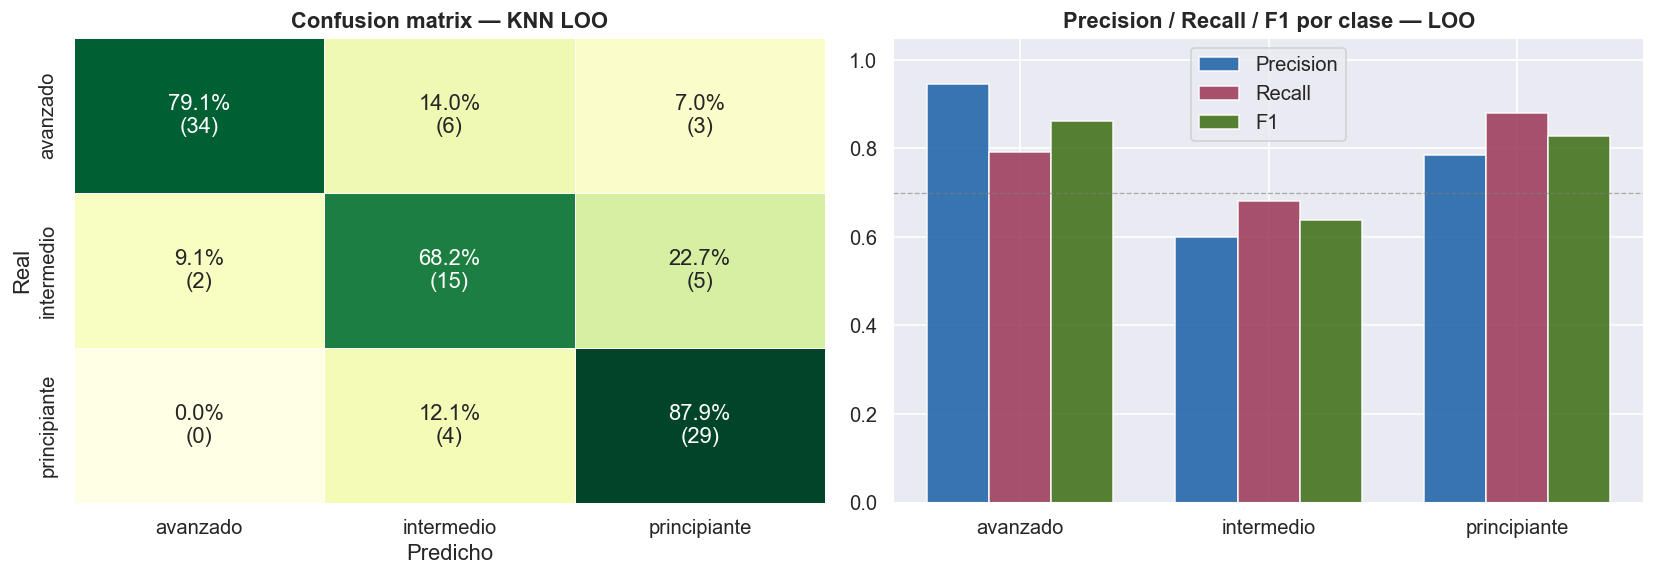

In [15]:
# ── Plots: confusion matrix + precision/recall/F1 por clase ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_norm = confusion_matrix(y_true_loo, y_pred_loo, normalize='true')
cm_raw  = confusion_matrix(y_true_loo, y_pred_loo)
annot   = np.array([
    [f'{cm_norm[i,j]*100:.1f}%\n({cm_raw[i,j]})' for j in range(3)]
    for i in range(3)
])
sns.heatmap(
    cm_norm, annot=annot, fmt='', cmap='YlGn',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, ax=axes[0], cbar=False
)
axes[0].set_title('Confusion matrix — KNN LOO', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

report_loo = classification_report(
    y_true_loo, y_pred_loo, target_names=le.classes_, output_dict=True
)
metrics_df = pd.DataFrame({
    c: {'Precision': report_loo[c]['precision'],
        'Recall':    report_loo[c]['recall'],
        'F1':        report_loo[c]['f1-score']}
    for c in le.classes_
}).T

x = np.arange(len(le.classes_))
w = 0.25
for i, (metric, color) in enumerate(
    zip(['Precision','Recall','F1'], ['#185FA5','#993556','#3B6D11'])
):
    axes[1].bar(x + i*w, metrics_df[metric], w, label=metric,
                color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(le.classes_)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Precision / Recall / F1 por clase — LOO', fontweight='bold')
axes[1].legend()
axes[1].axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# ── Análisis de errores — ¿qué usuarios se equivoca? ─────────────────────────
user_df['pred_loo']  = le.inverse_transform(y_pred_loo)
user_df['correcto']  = user_df['nivel_3class'] == user_df['pred_loo']
user_df['confianza'] = np.max(
    best_model_u.predict_proba(X_u), axis=1
) if hasattr(best_model_u, 'predict_proba') else np.nan

errores = user_df[~user_df['correcto']][[
    'Usuario', 'Rating_Usuario', 'nivel_3class', 'pred_loo',
    'win_rate', 'avg_teoria', 'avg_acl', 'n_games'
]].sort_values('Rating_Usuario')

print(f'Errores totales: {len(errores)}/{len(user_df)} usuarios')
print(f'Accuracy LOO: {(user_df["correcto"].sum()/len(user_df)):.3f}\n')
print(errores.to_string(index=False))

Errores totales: 23/98 usuarios
Accuracy LOO: 0.765

           Usuario  Rating_Usuario nivel_3class     pred_loo  win_rate  avg_teoria    avg_acl  n_games
              m0bz            1058 principiante   intermedio  0.532663    6.693467  88.707035      199
        WombatKucz            1188 principiante   intermedio  0.560302    7.628141 121.821608      199
       Kissapartio            1200 principiante   intermedio  0.505076    7.944162 113.523858      197
       Pressithole            1234 principiante   intermedio  0.502591    6.668394 113.022280      193
          sprEEEzy            1341 principiante   intermedio  0.510050    8.673367 159.329648      199
         AADESHGOW            1404   intermedio principiante  0.542929    7.636364 130.510101      198
          DimonFry            1460   intermedio principiante  0.527778    8.166667 169.779293      198
Girlsareplayerstoo            1610   intermedio principiante  0.446701    7.324873 121.245685      197
         Vicrosten  

## 9. Clustering de partidas — grupos naturales por comportamiento

En lugar de forzar etiquetas basadas en rating, se deja que el algoritmo
identifique **grupos naturales** de comportamiento a nivel de partida individual.

**Features de entrada**: `Fin_Teoria`, `acl_winsorized`, `game_prep_score`,
`game_risk_index`, `is_theory_expert`, `is_feeling_natural`, `is_critical_point`, `Victoria`.

**Metodología**:
1. Búsqueda del k óptimo con silhouette score y Davies-Bouldin index.
2. Clustering final con K-Means (k=3).
3. Validación cruzando clusters con rating (variable externa no vista por el algoritmo).
4. Clasificador supervisado sobre los clusters para estimar separabilidad.


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Features SOLO de apertura — sin rating, sin contexto usuario ──────────────
FEATURES_APERTURA = [
    f for f in [
        'Fin_Teoria',         # jugadas de teoría seguidas
        'acl_winsorized',     # pérdida de centipeones post-teoría
        'game_prep_score',    # preparación en la apertura
        'game_risk_index',    # riesgo tomado en apertura
        'is_theory_expert',   # domina la línea teórica
        'is_feeling_natural', # buena intuición post-teoría
        'is_critical_point',  # llegó a posición crítica sin estar preparado
        'Victoria',           # resultado (consecuencia de la apertura)
    ] if f in df.columns
]

print(f'Features de apertura ({len(FEATURES_APERTURA)}):')
for f in FEATURES_APERTURA:
    print(f'  {f}')

X_ap = df[FEATURES_APERTURA].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ap)

print(f'\nMuestras totales: {len(X_scaled):,} partidas')

Features de apertura (8):
  Fin_Teoria
  acl_winsorized
  game_prep_score
  game_risk_index
  is_theory_expert
  is_feeling_natural
  is_critical_point
  Victoria

Muestras totales: 17,986 partidas


  k=2  inertia=93,910  silhouette=0.387  DB=1.096
  k=3  inertia=75,475  silhouette=0.355  DB=1.268
  k=4  inertia=63,911  silhouette=0.368  DB=1.125
  k=5  inertia=45,927  silhouette=0.366  DB=0.894
  k=6  inertia=39,061  silhouette=0.382  DB=0.895
  k=7  inertia=32,553  silhouette=0.393  DB=0.858
  k=8  inertia=28,291  silhouette=0.402  DB=0.869


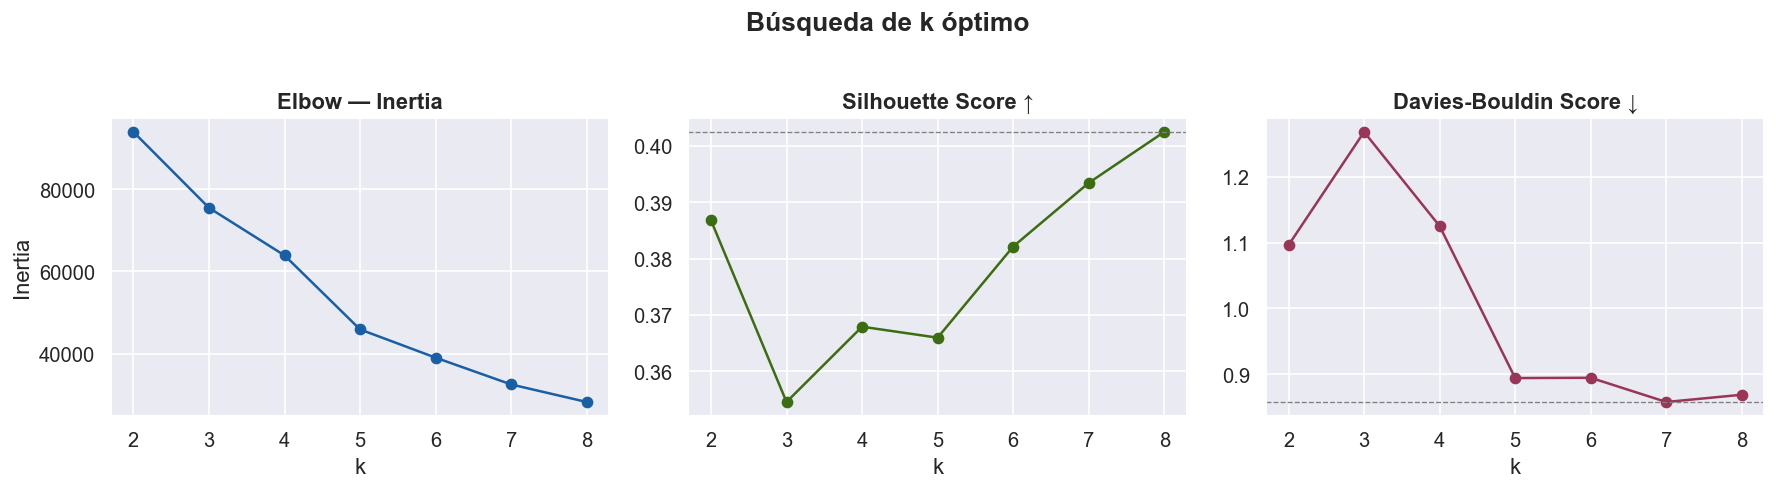

In [17]:
# ── Búsqueda del k óptimo (elbow + silhouette) ────────────────────────────────
inertias    = []
silhouettes = []
db_scores   = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'  k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.3f}  DB={db_scores[-1]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'o-', color='#185FA5')
axes[0].set_title('Elbow — Inertia', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='#3B6D11')
axes[1].set_title('Silhouette Score ↑', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].axhline(max(silhouettes), color='gray', linestyle='--', linewidth=0.8)

axes[2].plot(K_range, db_scores, 'o-', color='#993556')
axes[2].set_title('Davies-Bouldin Score ↓', fontweight='bold')
axes[2].set_xlabel('k')
axes[2].axhline(min(db_scores), color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Búsqueda de k óptimo', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ── Clustering final con k=3 ──────────────────────────────────────────────────
km3 = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = km3.fit_predict(X_scaled)

# Perfil de cada cluster
print('Perfil medio por cluster:')
perfil = df.groupby('cluster')[FEATURES_APERTURA + ['Rating_Usuario']].mean().round(3)
print(perfil.to_string())

print('\nDistribución de partidas por cluster:')
print(df['cluster'].value_counts().sort_index())

print('\nRating medio por cluster (referencia, NO es el target):')
print(df.groupby('cluster')['Rating_Usuario'].agg(['mean','std','min','max']).round(0))

Perfil medio por cluster:
         Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  is_theory_expert  is_feeling_natural  is_critical_point  Victoria  Rating_Usuario
cluster                                                                                                                                                 
0            12.419          97.632            0.828           20.181               1.0                 0.0                0.0     0.560        2037.054
1             4.299         106.398            0.287            7.171               0.0                 1.0                0.0     0.530        1595.055
2             7.945         122.831            0.530           15.197               0.0                 0.0                0.0     0.536        1705.344

Distribución de partidas por cluster:
cluster
0    6108
1    6912
2    4966
Name: count, dtype: int64

Rating medio por cluster (referencia, NO es el target):
           mean    std  min   max
cluster        

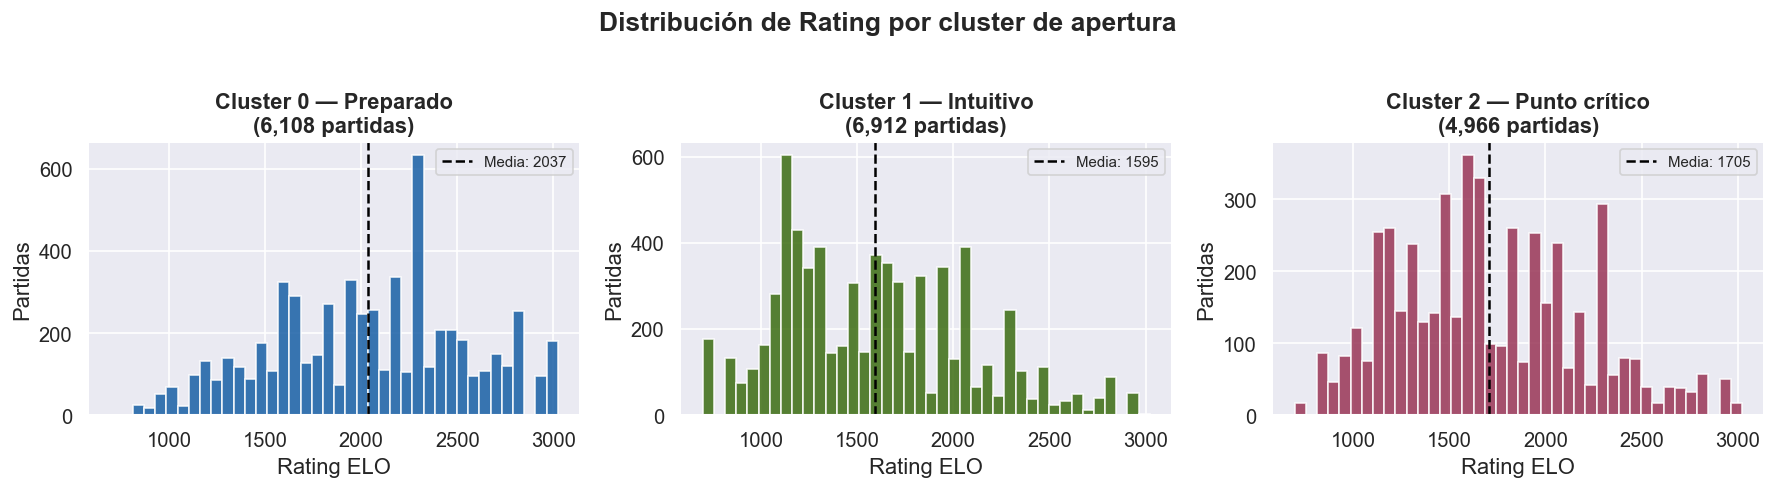

% de partidas de cada cluster por banda de rating:
             C0 Preparado  C1 Intuitivo  C2 Punto crítico
rating_band                                              
<1200                12.7          58.6              28.7
1200-1600            23.1          44.0              33.0
1600-2000            32.6          38.6              28.7
>2000                53.3          24.4              22.3

Distribución final:
cluster_nombre
Intuitivo        6912
Preparado        6108
Punto crítico    4966
Name: count, dtype: int64


In [19]:
# ── Distribución de rating por cluster ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

nombres = {0: 'Preparado', 1: 'Intuitivo', 2: 'Punto crítico'}
colores = {0: '#185FA5', 1: '#3B6D11', 2: '#993556'}

for c in range(3):
    subset = df[df['cluster'] == c]['Rating_Usuario']
    axes[c].hist(subset, bins=40, color=colores[c], edgecolor='white', alpha=0.85)
    axes[c].axvline(subset.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {subset.mean():.0f}')
    axes[c].set_title(f'Cluster {c} — {nombres[c]}\n({len(subset):,} partidas)',
                      fontweight='bold')
    axes[c].set_xlabel('Rating ELO')
    axes[c].set_ylabel('Partidas')
    axes[c].legend(fontsize=9)

plt.suptitle('Distribución de Rating por cluster de apertura', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Solapamiento entre clusters por nivel de rating ───────────────────────────
print('% de partidas de cada cluster por banda de rating:')
df['rating_band'] = pd.cut(df['Rating_Usuario'],
                            bins=[0, 1200, 1600, 2000, 5000],
                            labels=['<1200', '1200-1600', '1600-2000', '>2000'])
cross = pd.crosstab(df['rating_band'], df['cluster'],
                    normalize='index').round(3) * 100
cross.columns = [f'C{c} {nombres[c]}' for c in range(3)]
print(cross.to_string())

# ── Añadir nombre al cluster ───────────────────────────────────────────────────
df['cluster_nombre'] = df['cluster'].map(nombres)
print(f'\nDistribución final:')
print(df['cluster_nombre'].value_counts())

In [20]:
# ── Clasificador sobre clusters  ────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

y_cluster = df['cluster'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_ap_df = df[FEATURES_APERTURA].fillna(0)

models_cl = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=6,
        min_samples_leaf=10, random_state=42, n_jobs=-1
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=42))
    ]),
    'LightGBM': LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        num_leaves=31, min_child_samples=20,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

print('CV F1 weighted — target = cluster de apertura:')
print('─' * 50)
for name, model in models_cl.items():
    scores = cross_val_score(model, X_ap_df, y_cluster,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    print(f'  {name:20s}  {scores.mean():.3f} ± {scores.std():.3f}')

CV F1 weighted — target = cluster de apertura:
──────────────────────────────────────────────────
  Random Forest         1.000 ± 0.000
  SVM                   1.000 ± 0.000
  LightGBM              1.000 ± 0.000


In [21]:
print(cross.to_string())

             C0 Preparado  C1 Intuitivo  C2 Punto crítico
rating_band                                              
<1200                12.7          58.6              28.7
1200-1600            23.1          44.0              33.0
1600-2000            32.6          38.6              28.7
>2000                53.3          24.4              22.3


In [22]:
# Ver qué features son las que definen los clusters
print('Correlación de cada feature con el cluster:')
for f in FEATURES_APERTURA:
    corr = df[f].corr(df['cluster'])
    print(f'  {f:25s}  r={corr:.3f}')

# Ver si los flags binarios son mutuamente excluyentes
print('\n% de partidas con más de un flag activo:')
flags = ['is_theory_expert', 'is_feeling_natural', 'is_critical_point']
flags = [f for f in flags if f in df.columns]
multi = df[flags].sum(axis=1)
print(multi.value_counts().to_string())

Correlación de cada feature con el cluster:
  Fin_Teoria                 r=-0.511
  acl_winsorized             r=0.076
  game_prep_score            r=-0.511
  game_risk_index            r=-0.151
  is_theory_expert           r=-0.859
  is_feeling_natural         r=0.064
  is_critical_point          r=0.010
  Victoria                   r=-0.020

% de partidas con más de un flag activo:
1    13021
0     4965


### 9.1 Clustering con features continuas (sin flags binarios)

Los flags binarios pueden distorsionar el clustering al no ser mutuamente excluyentes
(hasta el 60% de las partidas tienen más de un flag activo).
Se repite el análisis solo con variables numéricas continuas.


In [23]:
# ── Clustering sin flags binarios — solo comportamiento continuo ──────────────
FEATURES_CONTINUAS = [
    f for f in [
        'Fin_Teoria',
        'acl_winsorized', 
        'game_prep_score',
        'game_risk_index',
    ] if f in df.columns
]

X_cont = df[FEATURES_CONTINUAS].fillna(0).values
X_cont_scaled = StandardScaler().fit_transform(X_cont)

# Búsqueda k óptimo
print('k   silhouette   DB')
print('─' * 30)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cont_scaled)
    sil = silhouette_score(X_cont_scaled, labels, sample_size=5000)
    db  = davies_bouldin_score(X_cont_scaled, labels)
    print(f'k={k}  sil={sil:.3f}  DB={db:.3f}')

k   silhouette   DB
──────────────────────────────
k=2  sil=0.391  DB=1.101
k=3  sil=0.420  DB=0.885
k=4  sil=0.407  DB=0.878
k=5  sil=0.372  DB=0.891
k=6  sil=0.383  DB=0.821


In [24]:
# ── Clustering final con k óptimo ─────────────────────────────────────────────
K_FINAL = 3  # ajusta según los scores anteriores

km_cont = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['cluster_cont'] = km_cont.fit_predict(X_cont_scaled)

# Ordenar clusters por acl_winsorized ascendente → 0=mejor, 2=peor
orden = (df.groupby('cluster_cont')['acl_winsorized']
           .mean()
           .sort_values()
           .index.tolist())
mapa  = {old: new for new, old in enumerate(orden)}
df['cluster_cont'] = df['cluster_cont'].map(mapa)

# Perfil
perfil = df.groupby('cluster_cont')[
    FEATURES_CONTINUAS + ['Rating_Usuario']
].mean().round(2)
perfil.index = ['nivel_0_solido', 'nivel_1_medio', 'nivel_2_debil']
print('Perfil por cluster (ordenado por ACL):')
print(perfil.to_string())

print('\nDistribución:')
print(df['cluster_cont'].value_counts().sort_index())

print('\nRating medio por cluster:')
print(df.groupby('cluster_cont')['Rating_Usuario']
        .agg(['mean','std','min','max']).round(0))

Perfil por cluster (ordenado por ACL):
                Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  Rating_Usuario
nivel_0_solido       11.87           51.86             0.79            12.39         2018.53
nivel_1_medio         5.22           66.89             0.35             6.03         1640.44
nivel_2_debil         8.91          323.06             0.59            37.68         1701.91

Distribución:
cluster_cont
0    5905
1    8851
2    3230
Name: count, dtype: int64

Rating medio por cluster:
                mean    std  min   max
cluster_cont                          
0             2019.0  514.0  696  3022
1             1640.0  492.0  696  3022
2             1702.0  523.0  696  3022


In [25]:
# ── Clasificador sobre nuevo clustering ───────────────────────────────────────
y_cont = df['cluster_cont'].values

print('CV F1 weighted — clusters sin flags:')
print('─' * 50)
for name, model in models_cl.items():
    scores = cross_val_score(
        model, df[FEATURES_CONTINUAS].fillna(0), y_cont,
        cv=skf, scoring='f1_weighted', n_jobs=-1
    )
    print(f'  {name:20s}  {scores.mean():.3f} ± {scores.std():.3f}')

# Crosstab rating vs nuevo cluster
print('\n% por banda de rating:')
cross2 = pd.crosstab(df['rating_band'], df['cluster_cont'],
                     normalize='index').round(3) * 100
cross2.columns = [f'C{c}' for c in range(K_FINAL)]
print(cross2.to_string())

CV F1 weighted — clusters sin flags:
──────────────────────────────────────────────────
  Random Forest         0.999 ± 0.001
  SVM                   0.999 ± 0.000
  LightGBM              0.999 ± 0.001

% por banda de rating:
               C0    C1    C2
rating_band                  
<1200        13.3  64.9  21.8
1200-1600    23.2  57.4  19.4
1600-2000    32.2  50.0  17.7
>2000        49.9  34.9  15.1


In [26]:
# ── Paso 1: etiquetar cada partida con su cluster de apertura ─────────────────
# (ya lo tenemos en df['cluster_cont'])

# ── Paso 2: agregar por usuario → perfil de apertura ─────────────────────────
# Target: cluster dominante del usuario (el que aparece más en sus partidas)
user_cluster = df.groupby('Usuario').agg(
    # Features de comportamiento agregadas
    avg_fin_teoria    = ('Fin_Teoria',       'mean'),
    avg_acl           = ('acl_winsorized',   'mean'),
    std_acl           = ('acl_winsorized',   'std'),
    avg_prep          = ('game_prep_score',  'mean'),
    avg_risk          = ('game_risk_index',  'mean'),
    win_rate          = ('Victoria',         'mean'),
    n_games           = ('Game_ID',          'count'),
    # Distribución de clusters del usuario
    pct_solido        = ('cluster_cont', lambda x: (x==0).mean()),
    pct_medio         = ('cluster_cont', lambda x: (x==1).mean()),
    pct_debil         = ('cluster_cont', lambda x: (x==2).mean()),
    # Target: cluster dominante
    cluster_dominante = ('cluster_cont', lambda x: x.mode()[0]),
    # Rating para referencia
    Rating_Usuario    = ('Rating_Usuario', 'mean'),
).reset_index()

user_cluster['std_acl'] = user_cluster['std_acl'].fillna(0)

print(f'Dataset a nivel usuario: {user_cluster.shape}')
print(f'\nDistribución cluster dominante:')
print(user_cluster['cluster_dominante'].value_counts().sort_index())
print(f'\nPerfil medio por cluster dominante:')
cols_perfil = ['avg_fin_teoria','avg_acl','avg_prep','avg_risk',
               'win_rate','pct_solido','pct_medio','pct_debil','Rating_Usuario']
print(user_cluster.groupby('cluster_dominante')[cols_perfil].mean().round(3).to_string())

Dataset a nivel usuario: (98, 13)

Distribución cluster dominante:
cluster_dominante
0    35
1    62
2     1
Name: count, dtype: int64

Perfil medio por cluster dominante:
                   avg_fin_teoria  avg_acl  avg_prep  avg_risk  win_rate  pct_solido  pct_medio  pct_debil  Rating_Usuario
cluster_dominante                                                                                                         
0                           9.899   95.319     0.660    15.842     0.628       0.521      0.310      0.168        2254.930
1                           6.872  115.716     0.458    12.376     0.472       0.202      0.613      0.185        1413.123
2                           8.673  159.330     0.578    20.690     0.510       0.286      0.347      0.367        1341.000


In [27]:
# ── Diagnóstico rápido ────────────────────────────────────────────────────────
print('¿Qué son los 2 usuarios del cluster 2?')
print(user_cluster[user_cluster['cluster_dominante']==2][
    ['Usuario','Rating_Usuario','avg_acl','avg_fin_teoria',
     'avg_prep','win_rate','pct_solido','pct_medio','pct_debil']
].to_string())

print('\n¿Cómo se distribuyen los pct por usuario?')
print(user_cluster[['pct_solido','pct_medio','pct_debil']].describe().round(3))

print('\nCorrelación pct_solido con Rating:')
print(user_cluster[['pct_solido','pct_medio','pct_debil','Rating_Usuario']].corr().round(3))

¿Qué son los 2 usuarios del cluster 2?
     Usuario  Rating_Usuario     avg_acl  avg_fin_teoria  avg_prep  win_rate  pct_solido  pct_medio  pct_debil
87  sprEEEzy          1341.0  159.329648        8.673367  0.578222   0.51005    0.286432   0.346734   0.366834

¿Cómo se distribuyen los pct por usuario?
       pct_solido  pct_medio  pct_debil
count      98.000     98.000     98.000
mean        0.317      0.502      0.181
std         0.183      0.184      0.063
min         0.000      0.050      0.041
25%         0.179      0.365      0.140
50%         0.289      0.503      0.177
75%         0.467      0.653      0.214
max         0.835      0.959      0.367

Correlación pct_solido con Rating:
                pct_solido  pct_medio  pct_debil  Rating_Usuario
pct_solido           1.000     -0.941     -0.161           0.813
pct_medio           -0.941      1.000     -0.182          -0.683
pct_debil           -0.161     -0.182      1.000          -0.374
Rating_Usuario       0.813     -0.683   

In [28]:
# La métrica más interesante no es el cluster dominante
# sino la VARIABILIDAD de cada jugador entre sus partidas
print(user_cluster[['pct_solido','pct_medio','pct_debil',
                     'Rating_Usuario']].describe().round(3))

# Hay jugadores con rating 1400 y 40% de partidas "sólidas
# Hay jugadores con rating 2000 y solo 20% de partidas "sólidas"
# ESOS son los casos interesantes para el sistema de recomendación

user_cluster['apertura_vs_rating'] = (
    user_cluster['pct_solido'] - 
    user_cluster['pct_solido'].mean()
) / user_cluster['pct_solido'].std()

user_cluster['rating_norm'] = (
    user_cluster['Rating_Usuario'] -
    user_cluster['Rating_Usuario'].mean()
) / user_cluster['Rating_Usuario'].std()

# Jugadores con mejor apertura que su rating sugiere
user_cluster['apertura_supera_rating'] = (
    user_cluster['apertura_vs_rating'] - user_cluster['rating_norm']
)

print('\nJugadores con MEJOR apertura que su rating:')
print(user_cluster.nlargest(5, 'apertura_supera_rating')[
    ['Usuario','Rating_Usuario','pct_solido','avg_acl','win_rate']
].to_string())

print('\nJugadores con PEOR apertura que su rating:')
print(user_cluster.nsmallest(5, 'apertura_supera_rating')[
    ['Usuario','Rating_Usuario','pct_solido','avg_acl','win_rate']
].to_string())

       pct_solido  pct_medio  pct_debil  Rating_Usuario
count      98.000     98.000     98.000          98.000
mean        0.317      0.502      0.181        1713.032
std         0.183      0.184      0.063         561.325
min         0.000      0.050      0.041         696.000
25%         0.179      0.365      0.140        1232.992
50%         0.289      0.503      0.177        1669.490
75%         0.467      0.653      0.214        2117.341
max         0.835      0.959      0.367        2984.500

Jugadores con MEJOR apertura que su rating:
           Usuario  Rating_Usuario  pct_solido     avg_acl  win_rate
22  Dipras_Kingdom           959.0    0.387755  118.302041  0.265306
90     taizya12345           940.0    0.291667  126.291667  0.500000
1    Abdulghani-HB          1992.4    0.580000   94.476000  0.542500
36     Kissapartio          1200.0    0.304569  113.523858  0.505076
88      stevobrine          1833.0    0.505155   90.704639  0.381443

Jugadores con PEOR apertura que su r

In [29]:
# ── Calcular la brecha apertura vs rating para todos los usuarios ─────────────
print('=== ANÁLISIS DE BRECHA APERTURA vs RATING ===\n')

print(user_cluster[['apertura_supera_rating','pct_solido',
                     'Rating_Usuario']].describe().round(3))

print('\n--- Top 10 mejor apertura vs rating ---')
print(user_cluster.nlargest(10, 'apertura_supera_rating')[
    ['Usuario','Rating_Usuario','pct_solido','pct_debil','avg_acl',
     'avg_fin_teoria','win_rate','apertura_supera_rating']
].to_string())

print('\n--- Top 10 peor apertura vs rating ---')
print(user_cluster.nsmallest(10, 'apertura_supera_rating')[
    ['Usuario','Rating_Usuario','pct_solido','pct_debil','avg_acl',
     'avg_fin_teoria','win_rate','apertura_supera_rating']
].to_string())

=== ANÁLISIS DE BRECHA APERTURA vs RATING ===

       apertura_supera_rating  pct_solido  Rating_Usuario
count                  98.000      98.000          98.000
mean                   -0.000       0.317        1713.032
std                     0.611       0.183         561.325
min                    -1.810       0.000         696.000
25%                    -0.361       0.179        1232.992
50%                     0.133       0.289        1669.490
75%                     0.440       0.467        2117.341
max                     1.731       0.835        2984.500

--- Top 10 mejor apertura vs rating ---
                Usuario  Rating_Usuario  pct_solido  pct_debil     avg_acl  avg_fin_teoria  win_rate  apertura_supera_rating
22       Dipras_Kingdom      959.000000    0.387755   0.204082  118.302041        9.142857  0.265306                1.730539
90          taizya12345      940.000000    0.291667   0.250000  126.291667        8.291667  0.500000                1.239031
1         Abdul

## 10. Clustering de aperturas sin leakage de rating

¿Puede el comportamiento en la apertura separar niveles de rating
**sin usar el rating como feature**?

Se excluye `Victoria` para evitar sesgo por resultado y el clustering solo ve
el comportamiento puro: teoría, precisión, preparación y riesgo.

La validación externa mediante Kruskal-Wallis sobre rating confirma si los clusters
son estadísticamente significativos.

### Etiquetas del clustering definitivo
| Cluster | Nombre | Descripción |
|---|---|---|
| 0 | `apertura_solida` | Alta teoría, baja pérdida de CP |
| 1 | `apertura_media` | Comportamiento intermedio |
| 2 | `apertura_debil` | Baja teoría, alta pérdida de CP |


In [30]:
# ── Features de apertura puras — nivel de cada partida individual ─────────────
FEATURES_PARTIDA = [
    f for f in [
        'Fin_Teoria',       # teoría jugada
        'acl_winsorized',   # error post-teoría (sin normalizar)
        'game_prep_score',  # preparación demostrada
        'game_risk_index',  # riesgo tomado
        'Victoria',         # resultado de la partida
    ] if f in df.columns
]

X_ind = df[FEATURES_PARTIDA].fillna(0)

print('Estadísticas de las features (sin normalizar):')
print(X_ind.describe().round(2).to_string())
print(f'\nTotal partidas: {len(X_ind):,}')

Estadísticas de las features (sin normalizar):
       Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  Victoria
count    17986.00        17986.00         17986.00         17986.00  17986.00
mean         8.06          107.96             0.54            13.80      0.54
std          3.79          128.90             0.25            15.13      0.49
min          0.00            0.00             0.00             0.00      0.00
25%          5.00            9.30             0.33             1.27      0.00
50%          8.00           61.20             0.53             9.24      1.00
75%         11.00          155.20             0.73            21.20      1.00
max         19.00          500.00             1.27            82.62      1.00

Total partidas: 17,986


In [31]:
# ── Búsqueda de k óptimo ──────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

scaler_ind  = StandardScaler()
X_ind_scaled = scaler_ind.fit_transform(X_ind)

print('k    silhouette    DB       inertia')
print('─' * 45)
sil_scores = []
db_scores  = []
inertias   = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_ind_scaled)
    sil = silhouette_score(X_ind_scaled, labels, sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X_ind_scaled, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    inertias.append(km.inertia_)
    print(f'k={k}   {sil:.4f}       {db:.4f}   {km.inertia_:,.0f}')

k    silhouette    DB       inertia
─────────────────────────────────────────────
k=2   0.3105       1.3843   61,660
k=3   0.3147       1.1699   46,232
k=4   0.3387       1.0881   36,758
k=5   0.3400       1.0847   31,277
k=6   0.3431       1.0525   26,515
k=7   0.3311       1.0007   23,656


In [32]:
# ── Clustering final ──────────────────────────────────────────────────────────
# Usa el k que tenga mejor silhouette y DB más bajo
K_FINAL = 3  # ajusta si los scores sugieren otro

km_ind = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['nivel_apertura_raw'] = km_ind.fit_predict(X_ind_scaled)

# Ordenar clusters por ACL ascendente → cluster 0 = mejor apertura
orden = (df.groupby('nivel_apertura_raw')['acl_winsorized']
           .mean().sort_values().index.tolist())
mapa  = {old: new for new, old in enumerate(orden)}
df['nivel_apertura'] = df['nivel_apertura_raw'].map(mapa)

# Perfil de cada cluster
perfil = df.groupby('nivel_apertura')[
    FEATURES_PARTIDA + ['Rating_Usuario']
].agg(['mean','std']).round(2)

print('Perfil por cluster (0=mejor apertura, N=peor):')
print(df.groupby('nivel_apertura')[
    FEATURES_PARTIDA + ['Rating_Usuario']
].mean().round(3).to_string())

print('\nDistribución de partidas:')
print(df['nivel_apertura'].value_counts().sort_index())

Perfil por cluster (0=mejor apertura, N=peor):
                Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  Victoria  Rating_Usuario
nivel_apertura                                                                                        
0                   11.866          51.750            0.791           12.373     0.554        2018.743
1                    5.216          66.938            0.348            6.029     0.530        1640.113
2                    8.918         322.538            0.594           37.673     0.551        1702.972

Distribución de partidas:
nivel_apertura
0    5899
1    8850
2    3237
Name: count, dtype: int64


In [33]:
# ── Validación supervisada — ¿correlaciona con rating? ───────────────────────
print('Distribución de rating por cluster de apertura:')
print(df.groupby('nivel_apertura')['Rating_Usuario']
        .agg(['mean','std','min','max']).round(0))

print('\n% de partidas por cluster según banda de rating:')
df['rating_band'] = pd.cut(
    df['Rating_Usuario'],
    bins=[0, 1200, 1600, 2000, 5000],
    labels=['<1200','1200-1600','1600-2000','>2000']
)
cross = pd.crosstab(
    df['rating_band'], df['nivel_apertura'],
    normalize='index'
).round(3) * 100
print(cross.to_string())

print('\nKruskal-Wallis — ¿es el rating significativamente distinto entre clusters?')
from scipy import stats
grupos = [df[df['nivel_apertura']==c]['Rating_Usuario'].values
          for c in range(K_FINAL)]
stat, p = stats.kruskal(*grupos)
print(f'  H={stat:.2f}  p={p:.6f}  {" significativo" if p < 0.05 else "❌ no significativo"}')

Distribución de rating por cluster de apertura:
                  mean    std  min   max
nivel_apertura                          
0               2019.0  514.0  696  3022
1               1640.0  492.0  696  3022
2               1703.0  523.0  696  3022

% de partidas por cluster según banda de rating:
nivel_apertura     0     1     2
rating_band                     
<1200           13.3  64.9  21.9
1200-1600       23.2  57.4  19.4
1600-2000       32.2  50.0  17.8
>2000           49.9  34.9  15.2

Kruskal-Wallis — ¿es el rating significativamente distinto entre clusters?
  H=1820.27  p=0.000000   significativo


In [34]:
# ── Comparar k=3 vs k=4 en detalle ───────────────────────────────────────────
for K in [3, 4]:
    km = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels_raw = km.fit_predict(X_ind_scaled)

    # Ordenar por ACL ascendente
    temp = df.copy()
    temp['lbl'] = labels_raw
    orden = temp.groupby('lbl')['acl_winsorized'].mean().sort_values().index.tolist()
    mapa  = {old: new for new, old in enumerate(orden)}
    temp['lbl'] = temp['lbl'].map(mapa)

    print(f'\n{"═"*60}')
    print(f'  k={K}')
    print(f'{"═"*60}')
    print(temp.groupby('lbl')[
        FEATURES_PARTIDA + ['Rating_Usuario']
    ].mean().round(2).to_string())
    print('\nDistribución:')
    print(temp['lbl'].value_counts().sort_index().to_string())
    print('\nRating medio:')
    print(temp.groupby('lbl')['Rating_Usuario']
              .agg(['mean','std']).round(0).to_string())
    print('\nCrosstab rating_band:')
    cross = pd.crosstab(df['rating_band'], temp['lbl'],
                        normalize='index').round(3)*100
    print(cross.to_string())


════════════════════════════════════════════════════════════
  k=3
════════════════════════════════════════════════════════════
     Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  Victoria  Rating_Usuario
lbl                                                                                        
0         11.87           51.75             0.79            12.37      0.55         2018.74
1          5.22           66.94             0.35             6.03      0.53         1640.11
2          8.92          322.54             0.59            37.67      0.55         1702.97

Distribución:
lbl
0    5899
1    8850
2    3237

Rating medio:
       mean    std
lbl               
0    2019.0  514.0
1    1640.0  492.0
2    1703.0  523.0

Crosstab rating_band:
lbl             0     1     2
rating_band                  
<1200        13.3  64.9  21.9
1200-1600    23.2  57.4  19.4
1600-2000    32.2  50.0  17.8
>2000        49.9  34.9  15.2

════════════════════════════════════════════════

In [35]:
# ── Clustering sin Victoria — nivel de apertura puro ─────────────────────────
FEATURES_APERTURA_PURA = [
    f for f in [
        'Fin_Teoria',
        'acl_winsorized',
        'game_prep_score',
        'game_risk_index',
    ] if f in df.columns
]

X_pura        = df[FEATURES_APERTURA_PURA].fillna(0)
scaler_pura   = StandardScaler()
X_pura_scaled = scaler_pura.fit_transform(X_pura)

print('k    silhouette    DB       inertia')
print('─' * 45)
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pura_scaled)
    sil = silhouette_score(X_pura_scaled, labels, sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X_pura_scaled, labels)
    print(f'k={k}   {sil:.4f}       {db:.4f}   {km.inertia_:,.0f}')

k    silhouette    DB       inertia
─────────────────────────────────────────────
k=2   0.3938       1.1007   43,702
k=3   0.4209       0.8855   28,256
k=4   0.4081       0.8778   21,781
k=5   0.3715       0.8906   17,279
k=6   0.3835       0.8211   14,570
k=7   0.3750       0.8496   12,399


In [36]:
# ── Dependencia: requiere Sección 1 (rutas) y Sección 10 (clustering) en memoria
# Si PKL_OUT no está definida, se resuelve automáticamente:
from pathlib import Path
if 'PKL_OUT' not in dir():
    PKL_OUT = Path().resolve().parent / 'data' / 'PKL'
    PKL_OUT.mkdir(parents=True, exist_ok=True)

# ── Clustering definitivo k=3 sin Victoria ────────────────────────────────────
km_pura = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_raw = km_pura.fit_predict(X_pura_scaled)

# Ordenar clusters por ACL ascendente → cluster 0 = mejor apertura (menos CP perdidos)
temp = df.copy()
temp['lbl'] = labels_raw
orden = (temp.groupby('lbl')['acl_winsorized']
             .mean().sort_values().index.tolist())
mapa_pura = {old: new for new, old in enumerate(orden)}
df['nivel_apertura'] = pd.Series(labels_raw).map(mapa_pura).values

# Etiquetas semánticas para facilitar la interpretación
NOMBRES_PURA = {0: 'apertura_solida', 1: 'apertura_media', 2: 'apertura_debil'}
df['nivel_apertura_nombre'] = df['nivel_apertura'].map(NOMBRES_PURA)

# ── Perfil y validación del clustering ────────────────────────────────────────
print('Perfil por cluster:')
print(df.groupby('nivel_apertura')[
    FEATURES_APERTURA_PURA + ['Victoria', 'Rating_Usuario']
].mean().round(3).to_string())
print('\nDistribución:')
print(df['nivel_apertura_nombre'].value_counts())
print('\nRating por cluster:')
print(df.groupby('nivel_apertura')['Rating_Usuario'].agg(['mean','std','min','max']).round(0))
print('\nCrosstab rating_band vs cluster:')
cross = pd.crosstab(df['rating_band'], df['nivel_apertura_nombre'],
                    normalize='index').round(3)*100
print(cross.to_string())

# Test de Kruskal-Wallis: ¿hay diferencias significativas de rating entre clusters?
print('\nKruskal-Wallis rating entre clusters:')
grupos = [df[df['nivel_apertura']==c]['Rating_Usuario'].values for c in range(3)]
stat, p = stats.kruskal(*grupos)
print(f'  H={stat:.2f}  p={p:.6f}  {" significativo" if p<0.05 else "❌ no significativo"}')
print('\nWin rate por cluster (validación externa):')
print(df.groupby('nivel_apertura_nombre')['Victoria'].mean().round(3))

# ── Serializar modelo de clustering a src/data/PKL/ ───────────────────────────
import joblib
joblib.dump(km_pura,     PKL_OUT / 'km_apertura_pura.pkl')
joblib.dump(scaler_pura, PKL_OUT / 'scaler_apertura_pura.pkl')
print(f'\n km_apertura_pura.pkl     → {PKL_OUT}')
print(f' scaler_apertura_pura.pkl → {PKL_OUT}')


Perfil por cluster:
                Fin_Teoria  acl_winsorized  game_prep_score  game_risk_index  Victoria  Rating_Usuario
nivel_apertura                                                                                        
0                   11.865          51.860            0.791           12.393     0.554        2018.528
1                    5.218          66.887            0.348            6.033     0.531        1640.435
2                    8.911         323.059            0.594           37.683     0.550        1701.915

Distribución:
nivel_apertura_nombre
apertura_media     8851
apertura_solida    5905
apertura_debil     3230
Name: count, dtype: int64

Rating por cluster:
                  mean    std  min   max
nivel_apertura                          
0               2019.0  514.0  696  3022
1               1640.0  492.0  696  3022
2               1702.0  523.0  696  3022

Crosstab rating_band vs cluster:
nivel_apertura_nombre  apertura_debil  apertura_media  apertura_solida

## 11. Perfil de apertura por usuario

Agregar las etiquetas de nivel de apertura (sólida / media / débil) al nivel de usuario.
Este perfil es la entrada principal del sistema de recomendación.

**Salida**: `src/data/CSV/user_opening_profiles.csv` — una fila por usuario con:
- Proporción de partidas en cada cluster de apertura.
- Estadísticas agregadas de comportamiento.
- Cluster dominante (el que concentra más partidas).


In [37]:
# ── Dependencia: requiere Sección 1 (rutas) y Sección 10 en memoria ─────────
from pathlib import Path
if 'CSV_OUT' not in dir():
    CSV_OUT  = Path().resolve().parent / 'data' / 'CSV'
    DATA_OUT = Path().resolve().parent / 'data'
    CSV_OUT.mkdir(parents=True, exist_ok=True)

# ── Agregar etiquetas de apertura a nivel de usuario ──────────────────────────
user_opening = df.groupby('Usuario').agg(
    Rating_Usuario    = ('Rating_Usuario',          'mean'),
    n_partidas        = ('Game_ID',                 'count'),
    pct_solida        = ('nivel_apertura',           lambda x: (x==0).mean()),
    pct_media         = ('nivel_apertura',           lambda x: (x==1).mean()),
    pct_debil         = ('nivel_apertura',           lambda x: (x==2).mean()),
    avg_fin_teoria    = ('Fin_Teoria',               'mean'),
    avg_acl           = ('acl_winsorized',           'mean'),
    avg_prep          = ('game_prep_score',          'mean'),
    avg_risk          = ('game_risk_index',          'mean'),
    win_rate          = ('Victoria',                 'mean'),
).reset_index()

# Cluster dominante: el que tiene mayor proporción de partidas
user_opening['cluster_dominante'] = (
    user_opening[['pct_solida','pct_media','pct_debil']]
    .idxmax(axis=1)
    .str.replace('pct_', 'apertura_', regex=False)
)

print(f'Perfil de apertura por usuario: {user_opening.shape}')
print('\nDistribución por cluster dominante:')
print(user_opening['cluster_dominante'].value_counts())
print('\nPerfil medio por cluster dominante:')
print(user_opening.groupby('cluster_dominante')[
    ['avg_fin_teoria','avg_acl','avg_prep','win_rate','pct_solida','pct_debil','Rating_Usuario']
].mean().round(3).to_string())

# ── Guardar en src/data/CSV/ ───────────────────────────────────────────────────
user_opening.to_csv(CSV_OUT / 'user_opening_profiles.csv', index=False)
user_opening.to_csv(DATA_OUT / 'user_opening_profiles.csv', index=False)
print(f'\n user_opening_profiles.csv → {CSV_OUT}')


Perfil de apertura por usuario: (98, 12)

Distribución por cluster dominante:
cluster_dominante
apertura_media     62
apertura_solida    35
apertura_debil      1
Name: count, dtype: int64

Perfil medio por cluster dominante:
                   avg_fin_teoria  avg_acl  avg_prep  win_rate  pct_solida  pct_debil  Rating_Usuario
cluster_dominante                                                                                    
apertura_debil              8.673  159.330     0.578     0.510       0.286      0.367        1341.000
apertura_media              6.872  115.716     0.458     0.472       0.202      0.185        1413.123
apertura_solida             9.899   95.319     0.660     0.628       0.521      0.168        2254.930

 user_opening_profiles.csv → C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV


## 12. Decision Tree interpretable — reglas de clasificación

Árbol de decisión entrenado sobre el perfil de usuario para generar reglas
legibles. Su objetivo **no** es maximizar el rendimiento predictivo sino
**explicar** qué umbrales de features separan los niveles.

Este árbol actúa como sistema de diagnóstico: dada la descripción de un usuario,
produce una ruta de decisión que justifica la clasificación asignada.

> Esta celda es **autocontenida**: carga directamente los artefactos serializados
> desde `src/data/PKL/` y `src/model/production/`, por lo que puede ejecutarse
> de forma independiente.


KMeans: k=3 | scaler features=4
Dataset: 74 partidas con ACL | 2 usuarios

Distribución niveles:
nivel_apertura
apertura_solida    30
apertura_media     28
apertura_debil     16

Features DT (6): ['Fin_Teoria', 'acl_winsorized', 'game_prep_score', 'game_risk_index', 'Color_enc', 'Victoria']
   Split desde CSV: 0 test | 74 train
   Test vacío — usando 10% del train como proxy

Split: 67 train | 7 test | Clases: ['apertura_debil', 'apertura_media', 'apertura_solida']

Accuracy → Train: 0.7164 | Test: 0.8571 | Gap: -0.1407  ⚠️ overfitting

REGLAS DEL ÁRBOL
|--- Fin_Teoria <= -0.134
|   |--- class: 1
|--- Fin_Teoria >  -0.134
|   |--- class: 2



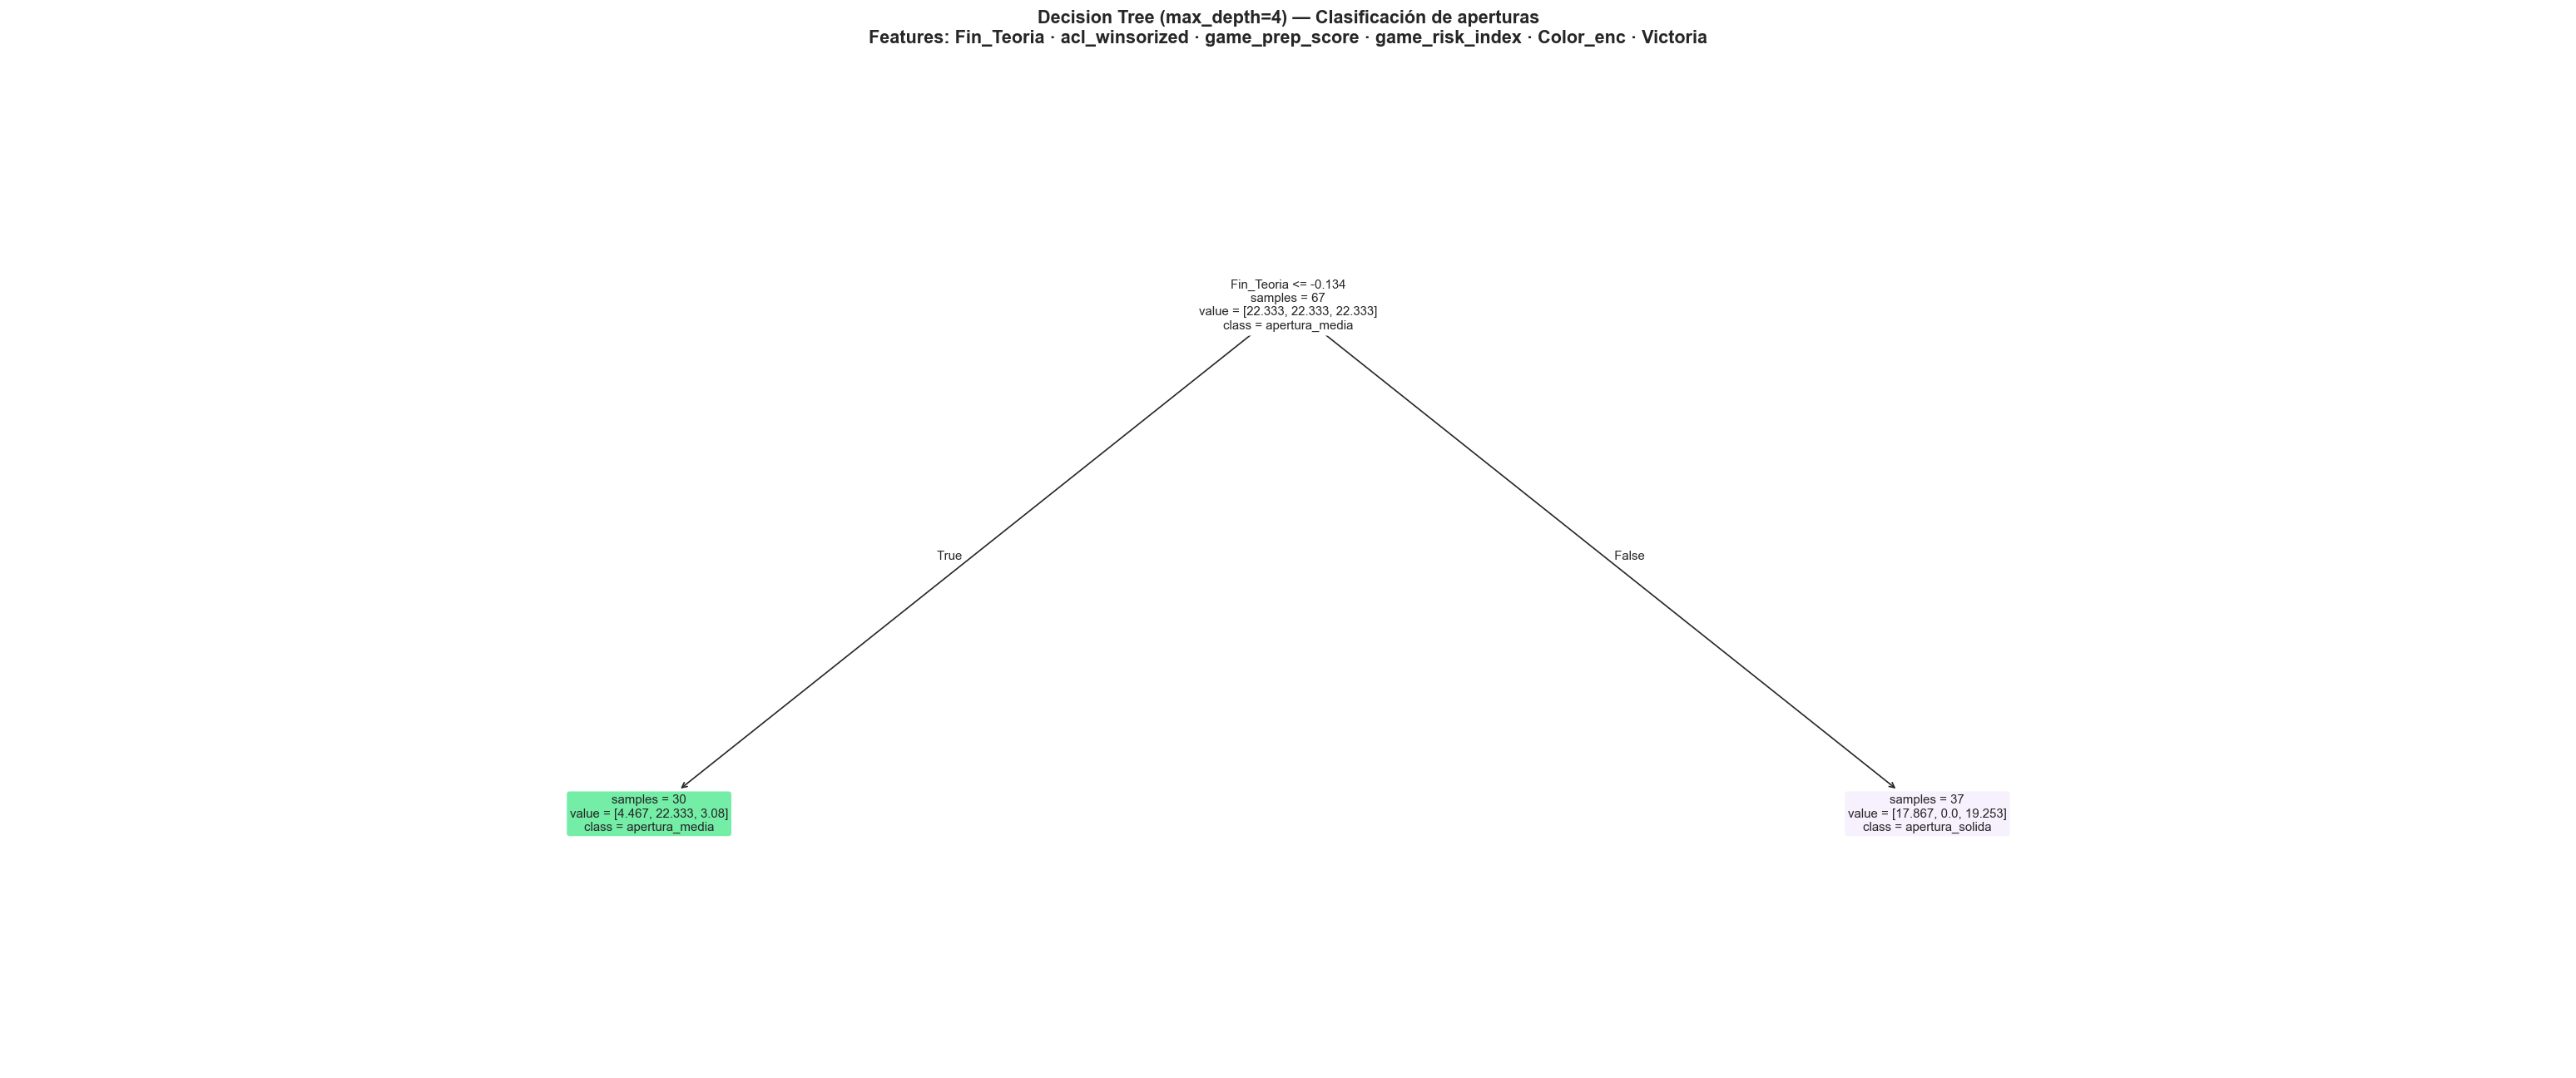

Árbol guardado: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\resources\img\decision_tree_aperturas.png

REGLAS POR HOJA

[01] APERTURA_SOLIDA    (37 partidas | 1.4%)
      Fin_Teoria >  -0.134

[02] APERTURA_MEDIA     (30 partidas | 2.5%)
      Fin_Teoria <= -0.134

Artefactos DT guardados en C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\model\production


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 12 — DECISION TREE INTERPRETABLE
# Autocontenida. Usa km_apertura_pura.pkl + master_game_level_ml.csv
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.tree          import DecisionTreeClassifier, export_text, plot_tree, _tree
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Rutas ─────────────────────────────────────────────────────────────────────
_NB_DIR   = Path().resolve()
CSV_OUT   = _NB_DIR.parent / "data" / "CSV"
PKL_OUT   = _NB_DIR.parent / "data" / "PKL"
MODEL_OUT = _NB_DIR.parent / "model" / "production"
DATA_OUT  = _NB_DIR.parent / "data"
IMG_OUT   = _NB_DIR.parent.parent / "resources" / "img"
IMG_OUT.mkdir(parents=True, exist_ok=True)

# ── Cargar modelos actuales (km_apertura_pura, sin leakage de rating) ─────────
km3    = joblib.load(PKL_OUT / "km_apertura_pura.pkl")
scaler = joblib.load(PKL_OUT / "scaler_apertura_pura.pkl")
cmap3  = {0: "apertura_solida", 1: "apertura_media", 2: "apertura_debil"}
print(f"KMeans: k={km3.n_clusters} | scaler features={scaler.n_features_in_}")

# ── Dataset — solo partidas con ACL real ──────────────────────────────────────
df = pd.read_csv(CSV_OUT / "master_game_level_ml.csv")
df = df[df["acl_winsorized"].notna() & (df["acl_winsorized"] > 0)].copy().reset_index(drop=True)
print(f"Dataset: {len(df):,} partidas con ACL | {df['Usuario'].nunique()} usuarios")

# ── Feature engineering on-the-fly ───────────────────────────────────────────
if "game_prep_score" not in df.columns:
    acc_tmp = df["acl_winsorized"].apply(
        lambda x: round(max(0, min(100, 100 * np.exp(-0.0035 * x))), 1)
    )
    df["game_prep_score"] = (df["Fin_Teoria"] / 15) * (acc_tmp / 100)
    df["game_risk_index"] = (df["Fin_Teoria"] / 15) * (100 - acc_tmp)

df["Color_enc"] = (df["Color"] == "Blancas").astype(int)

# ── Clasificar con KMeans actual ──────────────────────────────────────────────
FEATURES_KM = ["Fin_Teoria", "acl_winsorized", "game_prep_score", "game_risk_index"]
X_km = df[FEATURES_KM].fillna(0).values
df["nivel_apertura"] = [cmap3[l] for l in km3.predict(scaler.transform(X_km))]
print("\nDistribución niveles:")
print(df["nivel_apertura"].value_counts().to_string())

# ── Features para el DT ───────────────────────────────────────────────────────
FEATURE_COLS_CAND = ["Fin_Teoria", "acl_winsorized", "game_prep_score",
                     "game_risk_index", "Color_enc", "Victoria"]
FEATURE_COLS = [f for f in FEATURE_COLS_CAND if f in df.columns]
print(f"\nFeatures DT ({len(FEATURE_COLS)}): {FEATURE_COLS}")

le     = LabelEncoder()
y      = le.fit_transform(df["nivel_apertura"])
X      = df[FEATURE_COLS].fillna(0).values
CLASES = le.classes_

# ── Split por usuario — reutilizar Sección 3 ─────────────────────────────────
train_csv = DATA_OUT / "train.csv"
test_csv  = DATA_OUT / "test.csv"

if train_csv.exists() and test_csv.exists():
    usuarios_test_set = set(pd.read_csv(test_csv, usecols=["Usuario"])["Usuario"])
    mask_test         = df["Usuario"].isin(usuarios_test_set)
    print(f"   Split desde CSV: {mask_test.sum():,} test | {(~mask_test).sum():,} train")
else:
    usuarios  = df["Usuario"].unique()
    np.random.seed(42)
    u_test    = np.random.choice(usuarios, size=max(1, int(len(usuarios)*0.2)), replace=False)
    mask_test = df["Usuario"].isin(u_test)
    print("   Split recalculado")

X_train, X_test = X[~mask_test], X[mask_test]
y_train, y_test = y[~mask_test], y[mask_test]

if len(X_test) == 0:
    n = max(1, int(len(X_train) * 0.1))
    X_test, y_test   = X_train[-n:], y_train[-n:]
    X_train, y_train = X_train[:-n], y_train[:-n]
    print("   Test vacío — usando 10% del train como proxy")

sc_dt          = StandardScaler()
X_train_scaled = sc_dt.fit_transform(X_train)
X_test_scaled  = sc_dt.transform(X_test)
print(f"\nSplit: {len(X_train):,} train | {len(X_test):,} test | Clases: {list(CLASES)}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30,
                             class_weight="balanced", random_state=42)
dt.fit(X_train_scaled, y_train)

acc_train = dt.score(X_train_scaled, y_train)
acc_test  = dt.score(X_test_scaled,  y_test)
print(f"\nAccuracy → Train: {acc_train:.4f} | Test: {acc_test:.4f} | "
      f"Gap: {acc_train-acc_test:+.4f}  {'✅ OK' if abs(acc_train-acc_test)<0.1 else '⚠️ overfitting'}")

print("\n" + "="*62 + "\nREGLAS DEL ÁRBOL\n" + "="*62)
print(export_text(dt, feature_names=FEATURE_COLS, decimals=3))

# ── Visualización ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 11))
plot_tree(dt, feature_names=FEATURE_COLS, class_names=CLASES,
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=False)
plt.title(f"Decision Tree (max_depth=4) — Clasificación de aperturas\n"
          f"Features: {' · '.join(FEATURE_COLS)}", fontsize=13, fontweight="bold")
plt.tight_layout()
ruta_png = IMG_OUT / "decision_tree_aperturas.png"
plt.savefig(ruta_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Árbol guardado: {ruta_png}")

# ── Reglas por hoja ───────────────────────────────────────────────────────────
def extraer_reglas_hojas(tree_clf, feature_names, class_names):
    tree_  = tree_clf.tree_
    reglas = []
    def recurse(node, conds):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            clase     = class_names[tree_.value[node].argmax()]
            n_samples = int(tree_.n_node_samples[node])
            confianza = tree_.value[node].max() / tree_.n_node_samples[node]
            reglas.append({"clase": clase, "n_samples": n_samples,
                           "confianza": round(float(confianza), 3), "condiciones": list(conds)})
        else:
            feat   = feature_names[tree_.feature[node]]
            umbral = tree_.threshold[node]
            recurse(tree_.children_left[node],  conds + [f"{feat} <= {umbral:.3f}"])
            recurse(tree_.children_right[node], conds + [f"{feat} >  {umbral:.3f}"])
    recurse(0, [])
    return sorted(reglas, key=lambda r: r["n_samples"], reverse=True)

reglas = extraer_reglas_hojas(dt, FEATURE_COLS, CLASES)
print("\n" + "="*62 + "\nREGLAS POR HOJA\n" + "="*62)
for i, r in enumerate(reglas, 1):
    print(f"\n[{i:02d}] {r['clase'].upper():<18} ({r['n_samples']:,} partidas | {r['confianza']:.1%})")
    for c in r["condiciones"]:
        print(f"      {c}")

# ── Guardar artefactos ────────────────────────────────────────────────────────
joblib.dump(dt,           MODEL_OUT / "decision_tree_aperturas.pkl")
joblib.dump(sc_dt,        MODEL_OUT / "scaler_decision_tree.pkl")
joblib.dump(le,           MODEL_OUT / "label_encoder_dt.pkl")
joblib.dump(FEATURE_COLS, MODEL_OUT / "feature_cols_dt.pkl")
print(f"\nArtefactos DT guardados en {MODEL_OUT}")

## 13. Sistema de recomendación v2 — perfil individual

Primer recomendador: analiza el perfil **individual** del usuario e identifica
las aperturas con mayor necesidad de mejora.

### Lógica de niveles de apertura
| Nivel | Criterio | Acción recomendada |
|---|---|---|
| `sin_base` | Cluster débil + pocas partidas | Estudio urgente |
| `desarrollo` | Cluster medio | Profundizar |
| `dominio` | Cluster sólido | Mantener |

### Matching de recursos
El catálogo `chess_resources_v3.csv` se filtra por:
1. Apertura específica (tabla de sinónimos para variantes).
2. Rango de rating (`level_min` ≤ rating usuario ≤ `level_max`).
3. Ordenar por `rating_score` descendente (calidad) y `is_free` ascendente.

> El catálogo de recursos debe estar en `src/data/CSV/chess_resources_v3.csv`.


In [39]:
# ── Carga del catálogo de recursos de aprendizaje ─────────────────────────────
# El catálogo contiene cursos, libros y vídeos indexados por apertura y nivel
RECURSOS_PATH = CSV_OUT / 'chess_resources_v3.csv'
df_recursos = pd.read_csv(RECURSOS_PATH)
print('Columnas del catálogo:', df_recursos.columns.tolist())
print(f'Total de recursos disponibles: {len(df_recursos)}')
print(df_recursos.head(3).to_string())


Columnas del catálogo: ['resource_id', 'source', 'title', 'url', 'resource_type', 'format', 'course_type', 'openings', 'color', 'author', 'author_title', 'level_min', 'level_max', 'level_tier', 'duration_min', 'price_eur', 'is_free', 'has_video', 'has_pgn', 'has_exercises', 'has_spaced_rep', 'rating_score', 'views_yt', 'pub_date', 'description', 'level_tier_original', 'level_tier_source', 'level_tier_new']
Total de recursos disponibles: 1472
                                    resource_id        source                                                            title                                                                                                       url resource_type format course_type                openings  color                                   author author_title  level_min  level_max    level_tier  duration_min  price_eur  is_free  has_video  has_pgn  has_exercises  has_spaced_rep  rating_score  views_yt pub_date                                                  

In [40]:
# ── Pesos corregidos — rating fuera, clusters y accuracy al frente ────────────

PESOS_V2 = np.array([
    0.0,   # rating_medio      ← fuera: es consecuencia, no causa
    2.5,   # acc_media         ← señal principal
    2.5,   # teo_media         ← señal principal
    2.0,   # pct_dominio       ← perfil de clusters
    2.0,   # pct_desarrollo
    2.0,   # pct_sin_base
    1.0,   # win_rate          ← contexto secundario
    0.5,   # n_aperturas       ← diversidad, poco peso
])

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 13 — RECOMENDADOR v2 (PERFIL INDIVIDUAL)
# Autocontenida. Usa km_apertura_pura.pkl + master_game_level_ml.csv
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors     import NearestNeighbors

# ── Rutas ─────────────────────────────────────────────────────────────────────
_NB_DIR   = Path().resolve()
CSV_OUT   = _NB_DIR.parent / "data" / "CSV"
PKL_OUT   = _NB_DIR.parent / "data" / "PKL"

# ── Cargar modelos actuales ────────────────────────────────────────────────────
km3    = joblib.load(PKL_OUT / "km_apertura_pura.pkl")
scaler = joblib.load(PKL_OUT / "scaler_apertura_pura.pkl")
cmap3  = {0: "apertura_solida", 1: "apertura_media", 2: "apertura_debil"}

# ── Dataset ────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_OUT / "master_game_level_ml.csv")
df = df[df["acl_winsorized"].notna() & (df["acl_winsorized"] > 0)].copy().reset_index(drop=True)

if "game_prep_score" not in df.columns:
    acc_tmp = df["acl_winsorized"].apply(
        lambda x: round(max(0, min(100, 100 * np.exp(-0.0035 * x))), 1)
    )
    df["game_prep_score"] = (df["Fin_Teoria"] / 15) * (acc_tmp / 100)
    df["game_risk_index"] = (df["Fin_Teoria"] / 15) * (100 - acc_tmp)

df["Accuracy"] = df["acl_winsorized"].apply(
    lambda x: round(max(0.0, min(100.0, 100 * np.exp(-0.0035 * x))), 1)
)

# ── Clasificar con KMeans ─────────────────────────────────────────────────────
FEATURES_KM = ["Fin_Teoria", "acl_winsorized", "game_prep_score", "game_risk_index"]
X_km = df[FEATURES_KM].fillna(0).values
df["nivel_apertura"] = [cmap3[l] for l in km3.predict(scaler.transform(X_km))]

MAPA_NIVEL = {"apertura_debil": "sin_base", "apertura_media": "desarrollo",
              "apertura_solida": "dominio"}
df["nivel_rec"] = df["nivel_apertura"].map(MAPA_NIVEL).fillna("desarrollo")

# ── Catálogo ───────────────────────────────────────────────────────────────────
df_recursos = pd.read_csv(CSV_OUT / "chess_resources_v3.csv")
print(f"Dataset: {len(df):,} partidas | {df['Usuario'].nunique()} usuarios")
print(f"Catálogo: {len(df_recursos)} recursos")
print("\nDistribución niveles:")
print(df["nivel_apertura"].value_counts().to_string())

# ── Sinónimos ─────────────────────────────────────────────────────────────────
SINONIMOS = {
    "rapport-jobava system":   ["jobava", "london"],
    "jobava london":           ["jobava", "london"],
    "london system":           ["london"],
    "king's indian attack":    ["king's indian attack"],
    "king's indian defense":   ["king's indian"],
    "queen's indian defense":  ["queen's indian"],
    "nimzo-indian defense":    ["nimzo-indian"],
    "sicilian defense":        ["sicilian"],
    "caro-kann defense":       ["caro-kann"],
    "french defense":          ["french defense"],
    "queen's gambit declined": ["queen's gambit declined", "qgd"],
    "queen's gambit accepted": ["queen's gambit accepted", "qga"],
    "queen's gambit":          ["queen's gambit"],
    "slav defense":            ["slav defense", "slav"],
    "semi-slav defense":       ["semi-slav"],
    "queen's pawn game":       ["queen's pawn", "1.d4"],
    "king's pawn game":        ["king's pawn", "1.e4"],
    "english opening":         ["english opening"],
    "dutch defense":           ["dutch defense"],
    "ruy lopez":               ["ruy lopez", "spanish game"],
    "italian game":            ["italian game"],
    "grunfeld defense":        ["grunfeld"],
    "benoni defense":          ["benoni"],
}
NIVEL_PRIO = {"sin_base": 1, "desarrollo": 2, "dominio": 3}

def _terminos(apertura):
    ap = apertura.strip().lower()
    t  = [ap]
    for clave, sins in SINONIMOS.items():
        if clave in ap or ap in clave:
            t.extend(sins)
    return list(dict.fromkeys(t))

def buscar_recursos(apertura, df_rec, rating, nivel, top_n=3):
    terminos = _terminos(apertura)
    mask = df_rec["openings"].apply(
        lambda c: False if pd.isna(c) else any(t in c.lower() for t in terminos)
    )
    cands = df_rec[mask].copy()
    cands = cands[
        (cands["level_min"].fillna(0)    <= rating) &
        (cands["level_max"].fillna(9999) >= rating)
    ]
    if not cands.empty:
        cands = cands.sort_values(["rating_score", "is_free"], ascending=[False, True])
        return cands[["title","source","url","level_tier","is_free","course_type"]].head(top_n).to_dict("records")
    tier = "expert" if rating >= 2000 else ("intermediate" if rating >= 1200 else "beginner")
    fb   = df_rec[(df_rec["level_tier"] == tier) & (df_rec["course_type"] == "opening")].head(top_n)
    return fb[["title","source","url","level_tier","is_free","course_type"]].to_dict("records") if not fb.empty else []

def recomendar_v2(usuario, df_raw, df_rec, top_n_aperturas=5, top_n_recursos=3):
    df_u = df_raw[df_raw["Usuario"] == usuario].copy()
    if df_u.empty:
        return [], 0.0
    rating  = float(df_u["Rating_Usuario"].mean())
    resumen = (
        df_u.groupby(["Apertura", "Color", "nivel_rec"])
        .agg(n_partidas=("Game_ID","count"), acc_media=("Accuracy","mean"),
             win_rate=("Victoria","mean"))
        .reset_index()
    )
    resumen["prio"] = resumen["nivel_rec"].map(NIVEL_PRIO).fillna(2)
    resumen = (resumen[resumen["n_partidas"] >= 5]
               .sort_values(["prio","win_rate"], ascending=[True,True])
               .head(top_n_aperturas))
    recs = []
    for _, fila in resumen.iterrows():
        recursos = buscar_recursos(fila["Apertura"], df_rec, rating,
                                   fila["nivel_rec"], top_n_recursos)
        recs.append({
            "fuente": "v2", "apertura": fila["Apertura"], "nivel": fila["nivel_rec"],
            "color": fila["Color"], "n_partidas": int(fila["n_partidas"]),
            "acc_media": round(float(fila["acc_media"]), 1) if pd.notna(fila["acc_media"]) else None,
            "recursos": recursos,
        })
    return recs, rating

# ── Ejecutar sobre el usuario con más partidas ────────────────────────────────
usuario_test        = df.groupby("Usuario")["Game_ID"].count().sort_values(ascending=False).index[0]
recs_v2, rating_test = recomendar_v2(usuario_test, df, df_recursos)

libre = lambda r: "F" if r.get("is_free") == 1 else "P"
print(f"\n{'='*65}")
print(f"  PLAN v2  |  {usuario_test}  |  {rating_test:.0f} Elo")
print(f"{'='*65}")
for rec in recs_v2:
    print(f"\n  [{rec['nivel']}] {rec['apertura']} | {rec['color']} | "
          f"n={rec['n_partidas']} | acc={rec['acc_media']}%")
    for r in rec["recursos"]:
        print(f"     [{libre(r)}] {r['title'][:55]}")
        print(f"        {r['source']} · {r['level_tier']} · {r.get('url','')[:50]}")

Dataset: 74 partidas | 2 usuarios
Catálogo: 1472 recursos

Distribución niveles:
nivel_apertura
apertura_solida    30
apertura_media     28
apertura_debil     16

  PLAN v2  |  DemoledorI  |  1628 Elo

  [desarrollo] Sicilian Defense | Blancas | n=6 | acc=83.2%
     [F] Sicilian Defense Complete Guide
        youtube · intermediate · https://www.youtube.com/watch?v=0vXWdOHUsGs
     [P] The Sicilian Scheveningen
        chessable · advanced · https://www.chessable.com/course/search/?q=The%20S
     [P] The Sicilian Defense
        manual · intermediate · https://www.amazon.com/s?k=The%20Sicilian%20Defens

  [desarrollo] English Opening | Blancas | n=6 | acc=69.0%
     [P] The English Opening: A Comprehensive Guide
        chessable · advanced · https://www.chessable.com/course/search/?q=The%20E
     [P] 1.c4 e5 for Black - Flexible System with ...d6
        modern_chess · intermediate · https://www.modern-chess.com/course/1-c4-e5-for-bl
     [P] How Nimzo-Indian Players Can Meet 1.c4
   

## 14. Sistema de recomendación KNN — similitud entre usuarios

Segundo recomendador: busca los **k vecinos más similares** al usuario en el espacio
de comportamiento y detecta qué aperturas dominan esos vecinos pero no el usuario objetivo.

### Comparativa v1 vs v2
| Versión | Rating como feature | Objetivo |
|---|---|---|
| v1 | Sí | Vecinos similares en *nivel* |
| v2 | **No** (excluido) | Vecinos similares en *estilo de juego* |

### Pesos del espacio de similitud (v2)
| Feature | Peso | Justificación |
|---|---|---|
| `acc_media` | 2.5 | Señal principal de calidad |
| `teo_media` | 2.5 | Señal principal de conocimiento |
| `pct_dominio/desarrollo/sin_base` | 2.0 | Perfil de clusters |
| `win_rate` | 1.0 | Contexto secundario |
| `n_aperturas` | 0.5 | Diversidad del repertorio |
| `rating_medio` | **0.0** | Excluido (consecuencia, no causa) |

> Esta celda es **autocontenida** y carga los artefactos desde `src/data/PKL/`.


In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 14 — RECOMENDADOR KNN v2 (SIMILITUD ENTRE USUARIOS)
# Depende de variables de Sección 13 en memoria (df, df_recursos, cmap3,
# km3, scaler, FEATURES_KM, MAPA_NIVEL, buscar_recursos, usuario_test,
# recs_v2, rating_test). Si ejecutas sola, carga el bloque comentado abajo.
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.neighbors     import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd

# -- Descomenta si ejecutas esta celda de forma independiente ------------------
# import joblib; from pathlib import Path
# _NB_DIR = Path().resolve()
# CSV_OUT = _NB_DIR.parent / "data" / "CSV"
# PKL_OUT = _NB_DIR.parent / "data" / "PKL"
# km3    = joblib.load(PKL_OUT / "km_apertura_pura.pkl")
# scaler = joblib.load(PKL_OUT / "scaler_apertura_pura.pkl")
# cmap3  = {0: "apertura_solida", 1: "apertura_media", 2: "apertura_debil"}
# df = pd.read_csv(CSV_OUT / "master_game_level_ml.csv")
# df = df[df["acl_winsorized"].notna() & (df["acl_winsorized"] > 0)].copy().reset_index(drop=True)
# if "game_prep_score" not in df.columns:
#     acc_tmp = df["acl_winsorized"].apply(lambda x: round(max(0,min(100,100*np.exp(-0.0035*x))),1))
#     df["game_prep_score"] = (df["Fin_Teoria"]/15)*(acc_tmp/100)
#     df["game_risk_index"] = (df["Fin_Teoria"]/15)*(100-acc_tmp)
# df["Accuracy"] = df["acl_winsorized"].apply(lambda x: round(max(0.0,min(100.0,100*np.exp(-0.0035*x))),1))
# FEATURES_KM = ["Fin_Teoria","acl_winsorized","game_prep_score","game_risk_index"]
# df["nivel_apertura"] = [{0:"apertura_solida",1:"apertura_media",2:"apertura_debil"}[l]
#                         for l in km3.predict(scaler.transform(df[FEATURES_KM].fillna(0).values))]
# MAPA_NIVEL = {"apertura_debil":"sin_base","apertura_media":"desarrollo","apertura_solida":"dominio"}
# df["nivel_rec"] = df["nivel_apertura"].map(MAPA_NIVEL).fillna("desarrollo")
# df_recursos = pd.read_csv(CSV_OUT / "chess_resources_v3.csv")
# usuario_test = df.groupby("Usuario")["Game_ID"].count().sort_values(ascending=False).index[0]
# recs_v2, rating_test = [], float(df[df["Usuario"]==usuario_test]["Rating_Usuario"].mean())
# -- Fin bloque independiente --------------------------------------------------

K = 5

# ── Construir perfiles de usuario ─────────────────────────────────────────────
def construir_perfiles(df_raw):
    perfiles = []
    for usuario, grupo in df_raw.groupby("Usuario"):
        n      = len(grupo)
        counts = grupo.get("nivel_rec", pd.Series(dtype=str)).value_counts()
        perfiles.append({
            "Usuario":        usuario,
            "rating_medio":   grupo["Rating_Usuario"].mean(),
            "acc_media":      grupo["Accuracy"].mean() if "Accuracy" in grupo.columns else 50.0,
            "teo_media":      grupo["Fin_Teoria"].mean(),
            "pct_dominio":    counts.get("dominio",    0) / n,
            "pct_desarrollo": counts.get("desarrollo", 0) / n,
            "pct_sin_base":   counts.get("sin_base",   0) / n,
            "win_rate":       grupo["Victoria"].mean() if "Victoria" in grupo.columns else 0.5,
            "n_aperturas":    grupo["Apertura"].nunique() if "Apertura" in grupo.columns else 1,
        })
    df_out = pd.DataFrame(perfiles).set_index("Usuario")
    for col in df_out.columns:
        if df_out[col].isna().any():
            df_out[col] = df_out[col].fillna(df_out[col].median())
    return df_out

df_perfiles  = construir_perfiles(df)
usuarios_idx = df_perfiles.index.tolist()
print(f"Dataset: {len(df):,} partidas | {len(df_perfiles)} usuarios en perfiles KNN")

# ── KNN v2: sin rating, pesos sobre teoría + accuracy + clusters ──────────────
FEATURE_V2 = ["acc_media", "teo_media", "pct_dominio", "pct_desarrollo",
               "pct_sin_base", "win_rate", "n_aperturas"]
PESOS_V2   = np.array([2.5, 2.5, 2.0, 2.0, 2.0, 1.0, 0.5])

sc_v2  = StandardScaler()
X_v2   = sc_v2.fit_transform(df_perfiles[FEATURE_V2].fillna(0).values) * PESOS_V2
knn_v2 = NearestNeighbors(n_neighbors=min(K+1, len(df_perfiles)),
                           metric="cosine", algorithm="brute")
knn_v2.fit(X_v2)
print(f"KNN v2 listo — k={K} | features sin rating")

def recomendar_knn_v2(usuario, df_raw, df_rec, df_perf, knn_model,
                       sc, feat_cols, pesos, idx_list, k=5, top_n=3):
    if usuario not in df_perf.index:
        return [], 0.0
    rating = float(df_perf.loc[usuario, "rating_medio"])
    vec    = sc.transform(df_perf.loc[[usuario], feat_cols].fillna(0).values) * pesos
    dists, idxs = knn_model.kneighbors(vec)
    vecinos = [idx_list[i] for i, d in zip(idxs[0], dists[0])
               if idx_list[i] != usuario][:k]

    MIN_P = 5
    def ap_dom(u):
        sub = df_raw[(df_raw["Usuario"]==u) & (df_raw["nivel_apertura"]=="apertura_solida")]
        c   = sub.groupby("Apertura").size()
        return set(c[c >= MIN_P].index)

    ap_obj    = ap_dom(usuario)
    ap_vec    = {v: ap_dom(v) for v in vecinos}
    todas_vec = set().union(*ap_vec.values()) if ap_vec else set()
    gaps      = todas_vec - ap_obj
    freq_gap  = {ap: sum(1 for v_ap in ap_vec.values() if ap in v_ap) for ap in gaps}
    gaps_ord  = sorted(freq_gap.items(), key=lambda x: x[1], reverse=True)

    recs = []
    for apertura, freq in gaps_ord[:5]:
        recursos = buscar_recursos(apertura, df_rec, rating, "desarrollo", top_n)
        recs.append({"fuente": "knn", "apertura": apertura,
                     "freq_vecinos": freq, "k_total": k, "recursos": recursos})
    return recs, rating

recs_knn, _ = recomendar_knn_v2(
    usuario_test, df, df_recursos, df_perfiles,
    knn_v2, sc_v2, FEATURE_V2, PESOS_V2, usuarios_idx, k=K, top_n=3
)

libre = lambda r: "F" if r.get("is_free") == 1 else "P"
print(f"\n{'='*65}")
print(f"  PLAN KNN  |  {usuario_test}  |  vecinos: {K}")
print(f"{'='*65}")
if recs_knn:
    for rec in recs_knn:
        print(f"\n  {rec['apertura']} — en {rec['freq_vecinos']}/{K} vecinos")
        for r in rec["recursos"]:
            print(f"     [{libre(r)}] {r['title'][:55]}")
            print(f"        {r['source']} · {r['level_tier']} · {r.get('url','')[:50]}")
else:
    print("  Sin gaps detectados")

Dataset: 74 partidas | 2 usuarios en perfiles KNN
KNN v2 listo — k=5 | features sin rating

  PLAN KNN  |  DemoledorI  |  vecinos: 5
  Sin gaps detectados


## 15. Plan de estudio unificado  + KNN con deduplicación

Fusión de los dos recomendadores en un único plan de estudio con deduplicación.

### Sistema de scoring de recursos
| Fuente | Score base | Justificación |
|---|---|---|
| Solo v2 | 1.0 | Necesidad directa del perfil del usuario |
| Solo KNN | 0.8 | Gap detectado por similitud con pares |
| **Ambos** | **1.5** (+0.5 boost) | Señal reforzada — máxima prioridad |

El plan final se ordena por score descendente y se deduplica por `resource_id`
para evitar repeticiones. Los recursos que aparecen en ambos recomendadores
reciben un boost adicional de 0.5 (cap en 2.0).

> Esta celda es **autocontenida** y carga los artefactos desde `src/data/PKL/` y `src/data/CSV/`.


In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 15 — PLAN DE ESTUDIO UNIFICADO (v2 + KNN con deduplicación)
# Requiere recs_v2, recs_knn, rating_test, usuario_test de celdas anteriores.
# ═══════════════════════════════════════════════════════════════════════════════

NIVEL_PRIO_PLAN = {"sin_base": 1, "desarrollo": 2, "dominio": 3}

def fusionar_planes(recs_v2, recs_knn, rating):
    """
    Fusiona los dos recomendadores con deduplicación por URL/título.
    Scoring: solo v2=1.0 | solo knn=0.8 | ambos=1.5 (boost +0.5, cap 2.0)
    """
    recursos_vistos = {}
    plan_aperturas  = {}

    def registrar(apertura, meta, recursos, fuente, boost):
        if apertura not in plan_aperturas:
            plan_aperturas[apertura] = {**meta, "fuentes": set()}
        plan_aperturas[apertura]["fuentes"].add(fuente)
        for r in recursos:
            rid = r.get("url") or r.get("title", "sin_id")
            if rid not in recursos_vistos:
                recursos_vistos[rid] = {**r, "score": boost,
                                        "fuentes": {fuente}, "aperturas": [apertura]}
            else:
                recursos_vistos[rid]["score"]   += boost * 0.5
                recursos_vistos[rid]["fuentes"].add(fuente)
                if apertura not in recursos_vistos[rid]["aperturas"]:
                    recursos_vistos[rid]["aperturas"].append(apertura)

    for e in recs_v2:
        registrar(e["apertura"], {k:v for k,v in e.items() if k!="recursos"}, e["recursos"], "v2",  1.0)
    for e in recs_knn:
        registrar(e["apertura"], {k:v for k,v in e.items() if k!="recursos"}, e["recursos"], "knn", 0.8)

    for r in recursos_vistos.values():
        if len(r["fuentes"]) == 2:
            r["score"] = min(r["score"] + 0.5, 2.0)

    return plan_aperturas, sorted(recursos_vistos.values(), key=lambda x: x["score"], reverse=True)


def imprimir_plan(usuario, rating, plan_aperturas, recursos):
    SEP = "=" * 72
    ICONO = {"sin_base": "[!]", "desarrollo": "[+]", "dominio": "[ok]"}
    libre = lambda r: "F" if r.get("is_free") == 1 else "P"

    print(f"\n{SEP}")
    print(f"  PLAN UNIFICADO: {usuario}  |  {rating:.0f} Elo")
    print(f"{SEP}")
    print(f"\n  {'APERTURA':<33} {'NIVEL':<12} {'FUENTE':<9} {'N':>5} {'ACC':>6}")
    print(f"  {'-'*33} {'-'*12} {'-'*9} {'-'*5} {'-'*6}")

    for ap, meta in sorted(plan_aperturas.items(),
                           key=lambda x: NIVEL_PRIO_PLAN.get(x[1].get("nivel","dominio"), 2)):
        icono  = ICONO.get(meta.get("nivel",""), "   ")
        fuente = "+".join(sorted(meta["fuentes"]))
        print(f"  {icono} {ap[:28]:<28} {meta.get('nivel','?'):<12} {fuente:<9} "
              f"{str(meta.get('n_partidas','?')):>5} {str(meta.get('acc_media','?')):>6}")

    print(f"\n\n  RECURSOS (score desc, deduplicados)")
    print(f"  {'-'*68}")
    for i, r in enumerate(recursos[:10], 1):
        fuentes_str = "+".join(sorted(r["fuentes"]))
        boost_mark  = "**" if len(r["fuentes"]) == 2 else "  "
        print(f"\n  [{i:02d}] {boost_mark} score={r['score']:.2f}  [{fuentes_str}]")
        print(f"       [{libre(r)}] {r['title'][:60]}")
        if r.get("source"):
            print(f"          {r['source']} · {r.get('level_tier','?')} · {r.get('course_type','?')}")
        if r.get("url"):
            print(f"          {r['url']}")
        if len(r.get("aperturas",[])) > 1:
            print(f"          Cubre: {', '.join(r['aperturas'][:3])}")
    print(f"\n{SEP}\n")

# ── Ejecutar plan unificado ────────────────────────────────────────────────────
plan_ap, recursos_ord = fusionar_planes(recs_v2, recs_knn, rating_test)
imprimir_plan(usuario_test, rating_test, plan_ap, recursos_ord)


  PLAN UNIFICADO: DemoledorI  |  1628 Elo

  APERTURA                          NIVEL        FUENTE        N    ACC
  --------------------------------- ------------ --------- ----- ------
  [+] Sicilian Defense             desarrollo   v2            6   83.2
  [+] English Opening              desarrollo   v2            6   69.0
  [ok] Caro-Kann Defense            dominio      v2           14   86.8


  RECURSOS (score desc, deduplicados)
  --------------------------------------------------------------------

  [01]    score=1.00  [v2]
       [F] Sicilian Defense Complete Guide
          youtube · intermediate · opening
          https://www.youtube.com/watch?v=0vXWdOHUsGs

  [02]    score=1.00  [v2]
       [P] The Sicilian Scheveningen
          chessable · advanced · opening
          https://www.chessable.com/course/search/?q=The%20Sicilian%20Scheveningen

  [03]    score=1.00  [v2]
       [P] The Sicilian Defense
          manual · intermediate · opening
          https://www.amazon